# 03 — Deep Learning para radiografías: Sana / Neumonía / COVID-19

Este notebook documenta el módulo `ml-inference`: dataset, limpieza de `masks/`, preprocesamiento, entrenamiento, comparación CNN/ResNet18/EfficientNet-B0, métricas, matrices de confusión, criterio clínico e integración con dashboard.

ROOT = c:\Users\aripa\Downloads\Practica_Hospital_BACKUP_20260516_145943


# 03 — ML Inference: clasificación de radiografías

Este notebook explica el módulo `services/ml-inference`, responsable de clasificar radiografías de tórax en tres clases:

- **Sana**
- **Neumonía**
- **COVID-19**

El objetivo no es solo ejecutar un modelo, sino demostrar un flujo completo de Deep Learning aplicado a imágenes médicas:

1. Preparar el dataset.
2. Limpiar rutas incorrectas y excluir `masks/`.
3. Definir arquitecturas.
4. Entrenar modelos.
5. Evaluar con métricas clínicas.
6. Analizar matriz de confusión.
7. Comparar CNN simple, ResNet18 y EfficientNet-B0.
8. Elegir un modelo por criterio clínico, no solo por accuracy.
9. Exponer inferencia mediante FastAPI.
10. Integrar el resultado en dashboard y arquitectura Docker.

## 1. Estructura de `services/ml-inference`

El módulo se divide en dos partes:

| Carpeta | Función |
|---|---|
| `app/` | Servicio FastAPI de inferencia. Carga el modelo y expone `/healthz` y `/predict`. |
| `training/` | Código offline para preparar datos, entrenar, evaluar, comparar modelos y generar análisis crítico. |

Esto separa claramente:

- **Entrenamiento**: pesado, offline, reproducible.
- **Inferencia**: ligera, online, servida por API.

,archivo,líneas,tamaño_kb,elementos Python detectados
0,app/__init__.py,1,0.06,
1,app/app.py,136,4.50,"def health_check, def lifespan, def predict, d..."
2,app/config.py,20,0.64,
3,app/predictor.py,197,6.13,"class Predictor, def get_predictor, def is_mod..."
4,app/schemas.py,23,0.82,"class Config, class RadiographyPredictionOutput"
5,README.md,1347,35.29,
6,requirements.txt,11,0.19,
7,training/__init__.py,1,0.05,
8,training/augment.py,24,0.70,"def get_eval_transforms, def get_train_transforms"
9,training/compare_models.py,105,3.22,def main


## 2. Explicación archivo por archivo

Esta tabla resume para qué sirve cada archivo del módulo `ml-inference`.

...

### Por qué transfer learning

En imagen médica, entrenar una red profunda desde cero suele requerir muchísimas imágenes. En este proyecto usamos modelos preentrenados en ImageNet porque:

- convergen antes;
- reducen riesgo de sobreajuste;
- necesitan menos datos;
- dan mejor punto de partida;
- son viables dentro de Docker Compose.

La cabeza final se sustituye para producir tres clases.

## 7. Artefactos de modelos generados

Cada entrenamiento genera una carpeta versionada en `models/radiography/rx-*`.

Cada carpeta debe contener:

- `model.pt`
- `metadata.json`
- `history.csv`
- `history.json`
- `metrics.json`
- `confusion_matrix.png`
- `critical_analysis.md`

,version,backbone,accuracy,f1_macro,recall_covid,recall_neumonia,best_val_f1_macro,model.pt_MB,metrics.json,confusion_matrix.png,critical_analysis.md,ruta
0,rx-efficientnetb0-20260515-2b92eec9,efficientnet_b0,0.960000,0.960079,0.980000,0.933333,0.888084,15.564,True,True,True,models\radiography\rx-efficientnetb0-20260515-...
1,rx-resnet18-20260515-d397f8e5,resnet18,0.893333,0.892919,0.966667,0.833333,0.892065,42.708,True,True,True,models\radiography\rx-resnet18-20260515-d397f8e5
2,rx-simplecnn-20260515-e8ac76f0,simple_cnn,0.702222,0.701260,0.700000,0.773333,0.676096,1.500,True,True,True,models\radiography\rx-simplecnn-20260515-e8ac76f0


## 8. Comparación final de modelos

La comparación final se genera con `training.compare_models`.

El criterio de selección no es solo `accuracy`.

En contexto sanitario se prioriza:

- `f1_macro`;
- `recall_covid`;
- `recall_neumonia`;
- matriz de confusión;
- impacto clínico de falsos negativos.

,version,backbone,accuracy,f1_macro,recall_covid,recall_neumonia,best_val_f1_macro,test_rows,artifact_dir
0,rx-efficientnetb0-20260515-2b92eec9,efficientnet_b0,0.960000,0.960079,0.980000,0.933333,0.888084,450,/app/models/radiography/rx-efficientnetb0-2026...
1,rx-resnet18-20260515-d397f8e5,resnet18,0.893333,0.892919,0.966667,0.833333,0.892065,450,/app/models/radiography/rx-resnet18-20260515-d...
2,rx-simplecnn-20260515-e8ac76f0,simple_cnn,0.702222,0.701260,0.700000,0.773333,0.676096,450,/app/models/radiography/rx-simplecnn-20260515-...


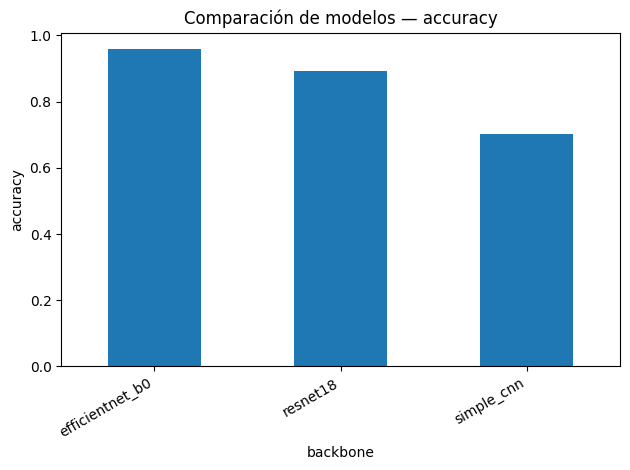

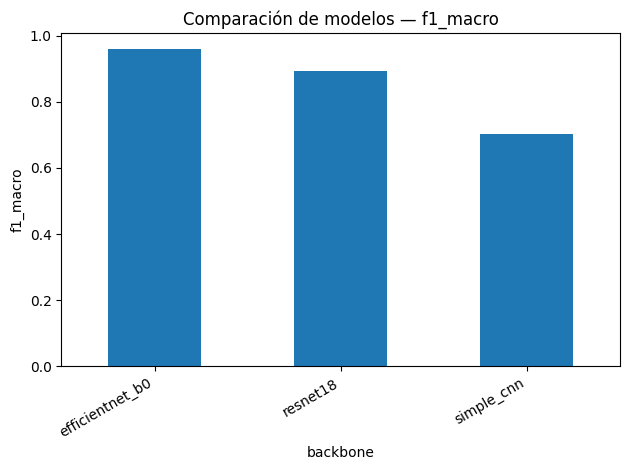

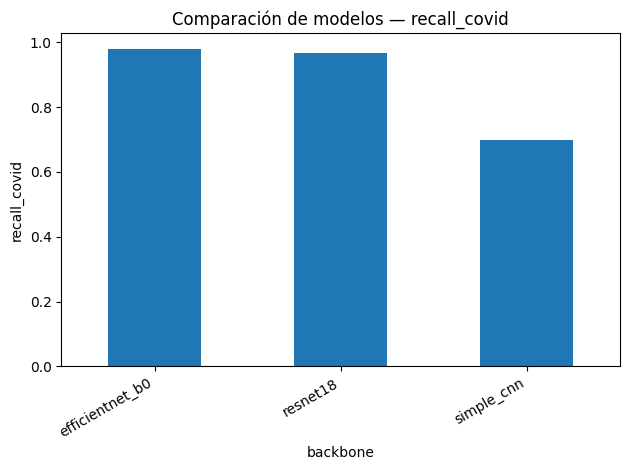

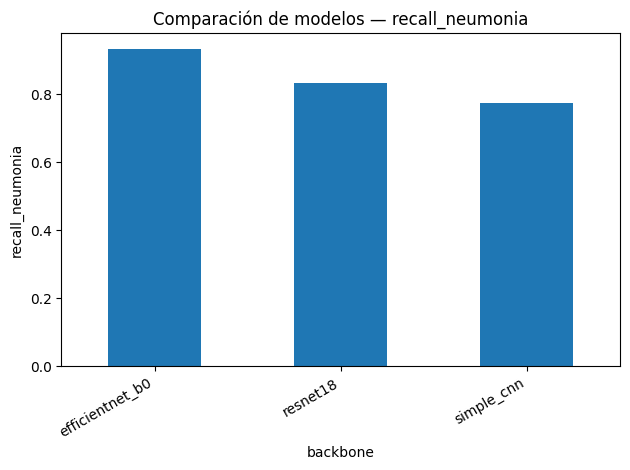

### Modelo seleccionado

El modelo seleccionado por equilibrio clínico es:

- **Versión:** `rx-efficientnetb0-20260515-2b92eec9`
- **Backbone:** `efficientnet_b0`
- **Accuracy:** `0.9600`
- **F1 macro:** `0.9601`
- **Recall COVID-19:** `0.9800`
- **Recall Neumonía:** `0.9333`

Se selecciona porque combina buen rendimiento global con alta sensibilidad en las clases clínicamente más relevantes.

### Informe `comparison.md`

# Comparación de modelos — radiografías

| Ranking | Versión | Backbone | Accuracy | F1 macro | Recall COVID | Recall Neumonía |
|---:|---|---|---:|---:|---:|---:|
| 1 | `rx-efficientnetb0-20260515-2b92eec9` | `efficientnet_b0` | 0.9600 | 0.9601 | 0.9800 | 0.9333 |
| 2 | `rx-resnet18-20260515-d397f8e5` | `resnet18` | 0.8933 | 0.8929 | 0.9667 | 0.8333 |
| 3 | `rx-simplecnn-20260515-e8ac76f0` | `simple_cnn` | 0.7022 | 0.7013 | 0.7000 | 0.7733 |

## Criterio de selección

El modelo no se selecciona solo por accuracy. En contexto hospitalario se priorizan F1 macro y recall de COVID-19/Neumonía para reducir falsos negativos clínicamente relevantes.

## 9. Matrices de confusión y análisis crítico

Para cada modelo se muestran:

1. Métricas principales.
2. Matriz de confusión numérica.
3. Matriz de confusión visual.
4. Análisis crítico generado.

Esto permite ver no solo cuánto acierta, sino **en qué se equivoca**.

---

### Modelo `rx-efficientnetb0-20260515-2b92eec9`

**Backbone:** `efficientnet_b0`

...

#### Matriz de confusión numérica

,Pred: Sana,Pred: Neumonía,Pred: COVID-19
Real: Sana,145,4,1
Real: Neumonía,10,140,0
Real: COVID-19,1,2,147


#### Errores principales

,clase_real,clase_predicha,casos
2,Neumonía,Sana,10
0,Sana,Neumonía,4
5,COVID-19,Neumonía,2
1,Sana,COVID-19,1
4,COVID-19,Sana,1
3,Neumonía,COVID-19,0


#### Matriz de confusión visual

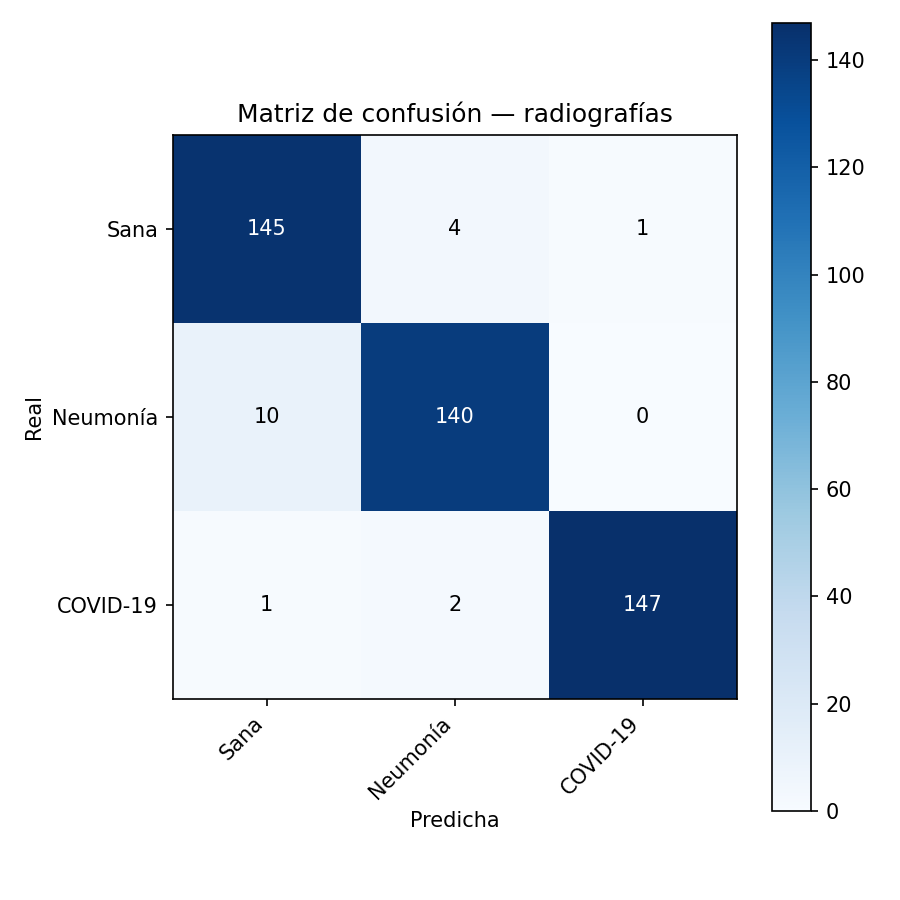

#### Análisis crítico generado

# Análisis crítico del modelo de radiografías `rx-efficientnetb0-20260515-2b92eec9`

## 1. Resumen técnico

- **Backbone**: `efficientnet_b0`
- **Accuracy**: 0.9600
- **F1 macro**: 0.9601
- **Recall COVID-19**: 0.9800
- **Recall Neumonía**: 0.9333

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Neumonía | Sana | 10 |
| 2 | Sana | Neumonía | 4 |
| 3 | COVID-19 | Neumonía | 2 |
| 4 | Sana | COVID-19 | 1 |
| 5 | COVID-19 | Sana | 1 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico: aislamiento, trazabilidad de contactos y protocolos COVID.

### Neumonía clasificada como sana

Implica retraso diagnóstico y terapéutico, especialmente problemático en pacientes vulnerables. Puede retrasar antibiótico, seguimiento o derivación.

### Sana clasificada como patológica

Es menos crítico que un falso negativo, pero genera sobrecarga asistencial, pruebas innecesarias, ansiedad del paciente y coste operativo.

## 4. Interpretación de sensibilidad

El recall COVID-19 (0.980) es razonable para un prototipo, aunque seguiría requiriendo validación clínica externa.

## 5. Limitaciones reales

- Dataset público con sesgos de adquisición, procedencia y calidad.
- No existe validación externa con datos hospitalarios propios.
- La clase `Neumonía` agrupa `Viral Pneumonia` y `Lung_Opacity`, simplificando una realidad clínica más compleja.
- El modelo puede aprender artefactos del dataset en lugar de patrones radiológicos generalizables.
- El sistema no sustituye criterio médico ni constituye dispositivo médico certificado.

## 6. Conclusión

El modelo es válido como módulo académico de Deep Learning integrado en una infraestructura Big Data hospitalaria. Para producción real harían falta más datos, validación multicéntrica, revisión radiológica experta, calibración de probabilidades y certificación regulatoria.

---

### Modelo `rx-resnet18-20260515-d397f8e5`

**Backbone:** `resnet18`

,métrica,valor
0,accuracy,0.893333
1,f1_macro,0.892919
2,recall_covid,0.966667
3,recall_neumonia,0.833333


#### Métricas por clase

...

#### Matriz de confusión numérica

,Pred: Sana,Pred: Neumonía,Pred: COVID-19
Real: Sana,132,5,13
Real: Neumonía,21,125,4
Real: COVID-19,3,2,145


#### Errores principales

,clase_real,clase_predicha,casos
2,Neumonía,Sana,21
1,Sana,COVID-19,13
0,Sana,Neumonía,5
3,Neumonía,COVID-19,4
4,COVID-19,Sana,3
5,COVID-19,Neumonía,2


#### Matriz de confusión visual

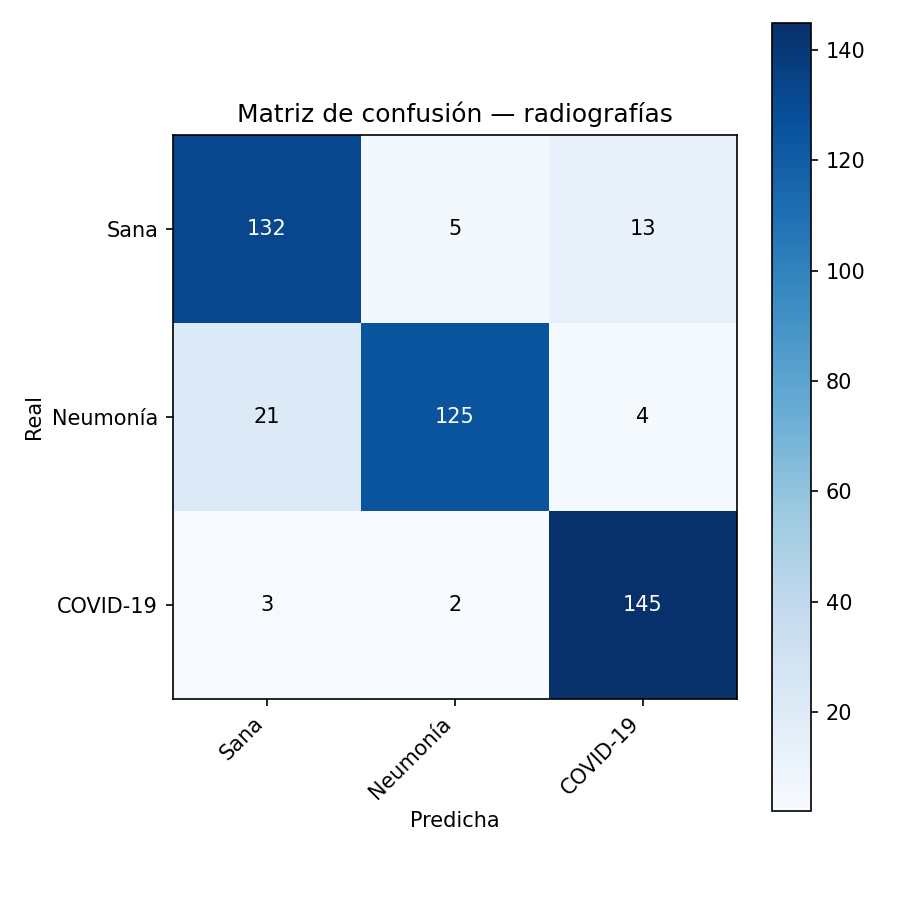

#### Análisis crítico generado

# Análisis crítico del modelo de radiografías `rx-resnet18-20260515-d397f8e5`

## 1. Resumen técnico

- **Backbone**: `resnet18`
- **Accuracy**: 0.8933
- **F1 macro**: 0.8929
- **Recall COVID-19**: 0.9667
- **Recall Neumonía**: 0.8333

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Neumonía | Sana | 21 |
| 2 | Sana | COVID-19 | 13 |
| 3 | Sana | Neumonía | 5 |
| 4 | Neumonía | COVID-19 | 4 |
| 5 | COVID-19 | Sana | 3 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico: aislamiento, trazabilidad de contactos y protocolos COVID.

### Neumonía clasificada como sana

Implica retraso diagnóstico y terapéutico, especialmente problemático en pacientes vulnerables. Puede retrasar antibiótico, seguimiento o derivación.

### Sana clasificada como patológica

Es menos crítico que un falso negativo, pero genera sobrecarga asistencial, pruebas innecesarias, ansiedad del paciente y coste operativo.

## 4. Interpretación de sensibilidad

El recall COVID-19 (0.967) es razonable para un prototipo, aunque seguiría requiriendo validación clínica externa.

## 5. Limitaciones reales

- Dataset público con sesgos de adquisición, procedencia y calidad.
- No existe validación externa con datos hospitalarios propios.
- La clase `Neumonía` agrupa `Viral Pneumonia` y `Lung_Opacity`, simplificando una realidad clínica más compleja.
- El modelo puede aprender artefactos del dataset en lugar de patrones radiológicos generalizables.
- El sistema no sustituye criterio médico ni constituye dispositivo médico certificado.

## 6. Conclusión

El modelo es válido como módulo académico de Deep Learning integrado en una infraestructura Big Data hospitalaria. Para producción real harían falta más datos, validación multicéntrica, revisión radiológica experta, calibración de probabilidades y certificación regulatoria.

---

### Modelo `rx-simplecnn-20260515-e8ac76f0`

**Backbone:** `simple_cnn`

,métrica,valor
0,accuracy,0.702222
1,f1_macro,0.701260
2,recall_covid,0.700000
3,recall_neumonia,0.773333


#### Métricas por clase

...

#### Matriz de confusión numérica

,Pred: Sana,Pred: Neumonía,Pred: COVID-19
Real: Sana,95,21,34
Real: Neumonía,16,116,18
Real: COVID-19,21,24,105


#### Errores principales

,clase_real,clase_predicha,casos
1,Sana,COVID-19,34
5,COVID-19,Neumonía,24
0,Sana,Neumonía,21
4,COVID-19,Sana,21
3,Neumonía,COVID-19,18
2,Neumonía,Sana,16


#### Matriz de confusión visual

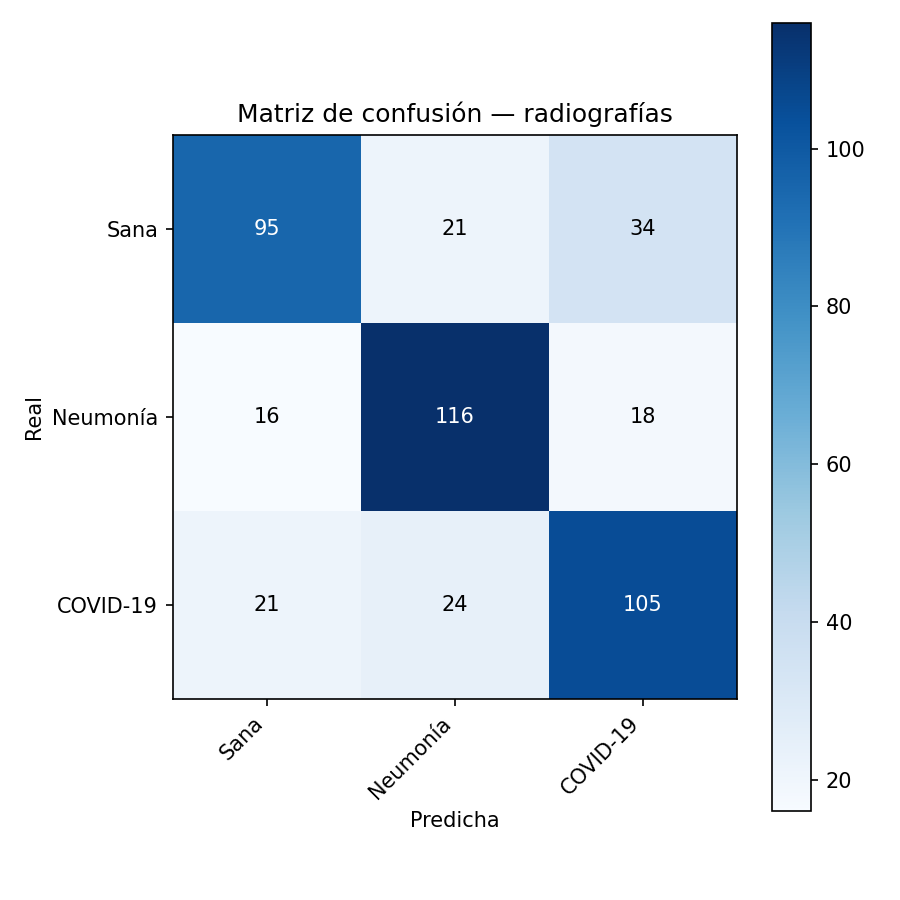

#### Análisis crítico generado

# Análisis crítico del modelo de radiografías `rx-simplecnn-20260515-e8ac76f0`

## 1. Resumen técnico

- **Backbone**: `simple_cnn`
- **Accuracy**: 0.7022
- **F1 macro**: 0.7013
- **Recall COVID-19**: 0.7000
- **Recall Neumonía**: 0.7733

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Sana | COVID-19 | 34 |
| 2 | COVID-19 | Neumonía | 24 |
| 3 | Sana | Neumonía | 21 |
| 4 | COVID-19 | Sana | 21 |
| 5 | Neumonía | COVID-19 | 18 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico: aislamiento, trazabilidad de contactos y protocolos COVID.

### Neumonía clasificada como sana

Implica retraso diagnóstico y terapéutico, especialmente problemático en pacientes vulnerables. Puede retrasar antibiótico, seguimiento o derivación.

### Sana clasificada como patológica

Es menos crítico que un falso negativo, pero genera sobrecarga asistencial, pruebas innecesarias, ansiedad del paciente y coste operativo.

## 4. Interpretación de sensibilidad

El recall COVID-19 (0.700) es insuficiente para uso clínico real. El modelo puede servir como demostrador académico, pero no como herramienta autónoma de cribado.

## 5. Limitaciones reales

- Dataset público con sesgos de adquisición, procedencia y calidad.
- No existe validación externa con datos hospitalarios propios.
- La clase `Neumonía` agrupa `Viral Pneumonia` y `Lung_Opacity`, simplificando una realidad clínica más compleja.
- El modelo puede aprender artefactos del dataset en lugar de patrones radiológicos generalizables.
- El sistema no sustituye criterio médico ni constituye dispositivo médico certificado.

## 6. Conclusión

El modelo es válido como módulo académico de Deep Learning integrado en una infraestructura Big Data hospitalaria. Para producción real harían falta más datos, validación multicéntrica, revisión radiológica experta, calibración de probabilidades y certificación regulatoria.

## 10. Históricos de entrenamiento

Si existe `history.csv`, se muestran las curvas de entrenamiento y validación.

### Histórico `rx-efficientnetb0-20260515-2b92eec9`

,epoch,phase,train_loss,train_f1_macro,val_loss,val_f1_macro
0,1,warmup,0.851666,0.620647,0.704409,0.719237
1,2,warmup,0.686072,0.725576,0.611908,0.771331
2,3,finetune,0.494177,0.809748,0.360413,0.862587
3,4,finetune,0.334563,0.872442,0.321629,0.885365
4,5,finetune,0.279094,0.894902,0.376393,0.866237


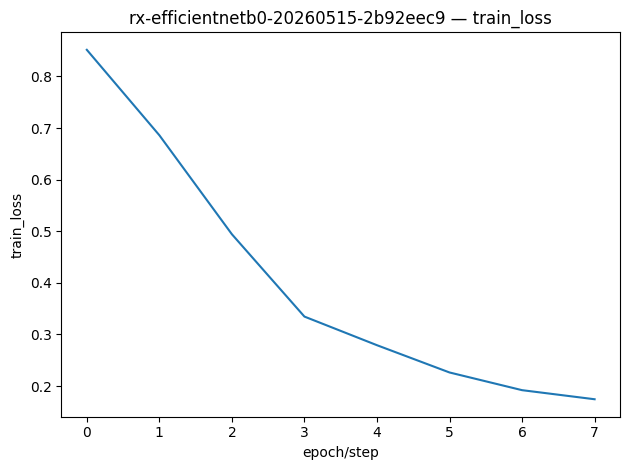

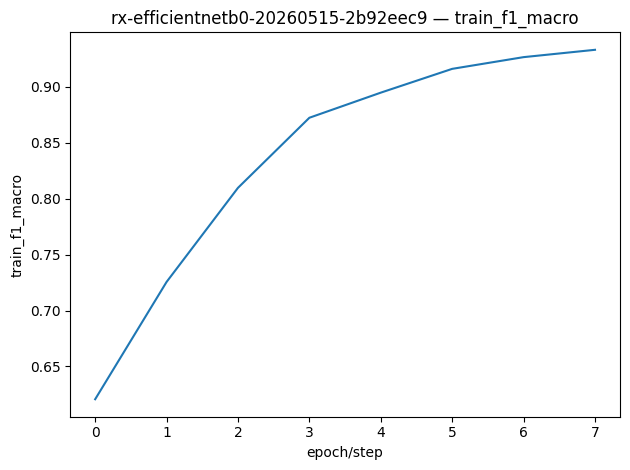

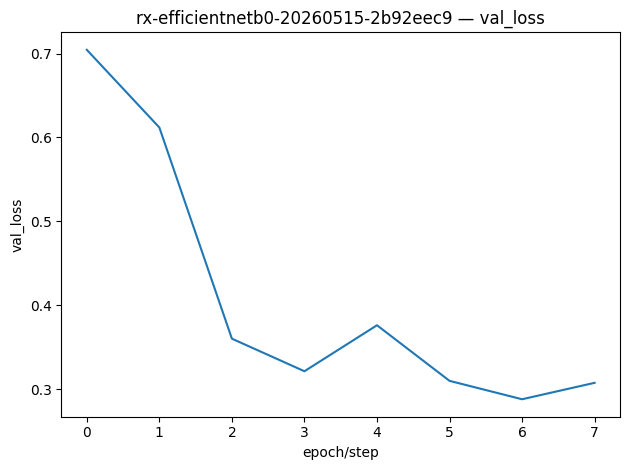

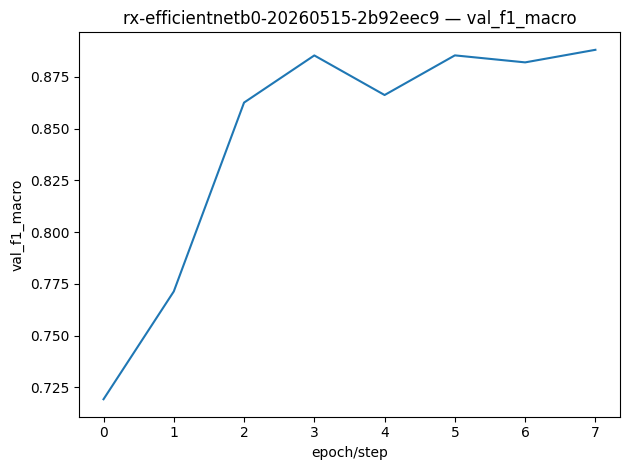

### Histórico `rx-resnet18-20260515-d397f8e5`

,epoch,phase,train_loss,train_f1_macro,val_loss,val_f1_macro
0,1,warmup,0.890967,0.594389,0.928691,0.495876
1,2,warmup,0.775890,0.649997,0.821416,0.582407
2,3,finetune,0.541692,0.800295,0.366385,0.860538
3,4,finetune,0.364627,0.871814,0.455764,0.829399
4,5,finetune,0.286330,0.889464,0.534582,0.818662


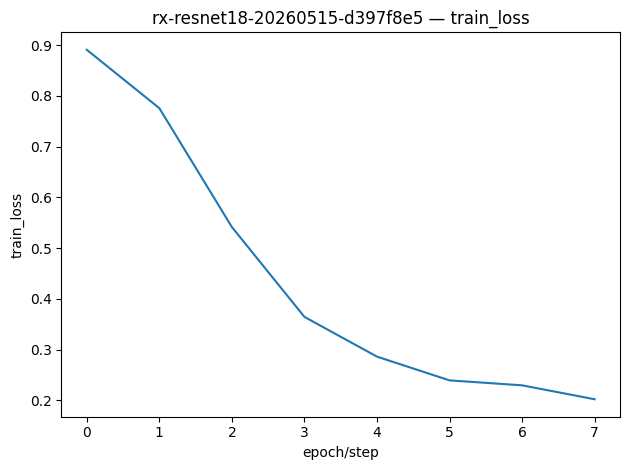

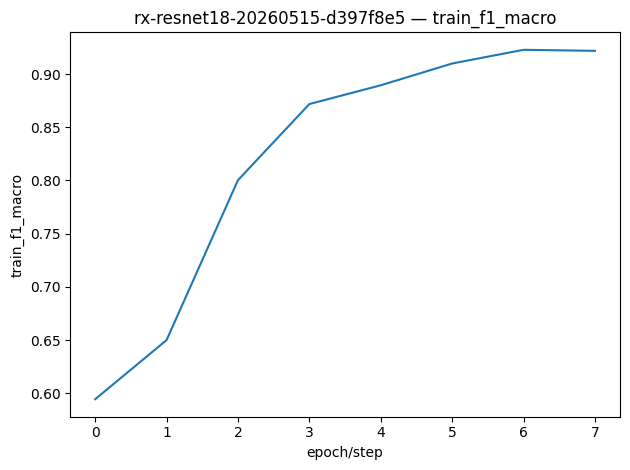

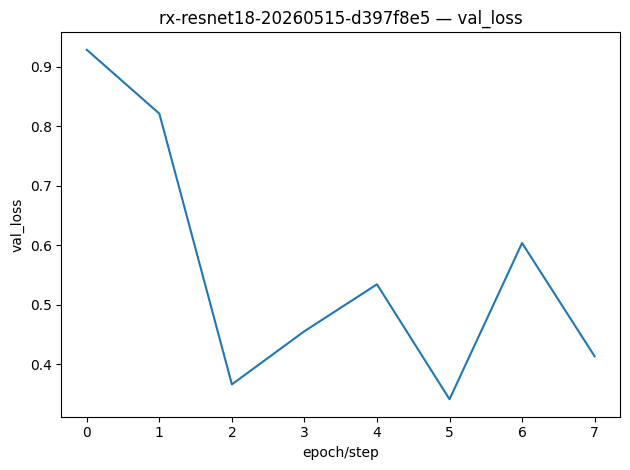

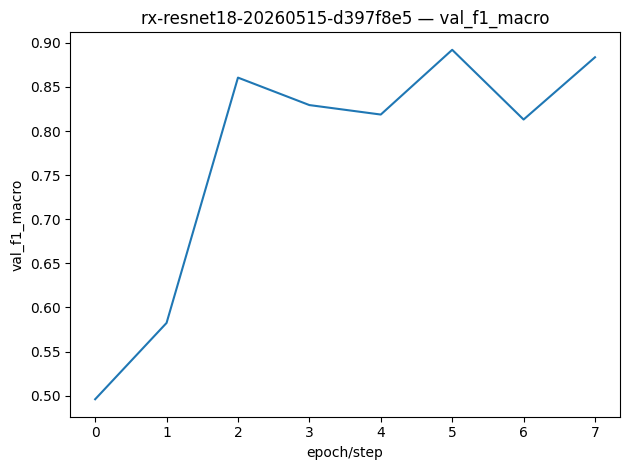

### Histórico `rx-simplecnn-20260515-e8ac76f0`

,epoch,phase,train_loss,train_f1_macro,val_loss,val_f1_macro
0,1,finetune,1.020139,0.506543,0.980906,0.527691
1,2,finetune,0.954557,0.563017,0.945614,0.604155
2,3,finetune,0.921677,0.587990,0.934394,0.565094
3,4,finetune,0.892859,0.606382,0.849174,0.636349
4,5,finetune,0.886107,0.598848,0.831451,0.661213


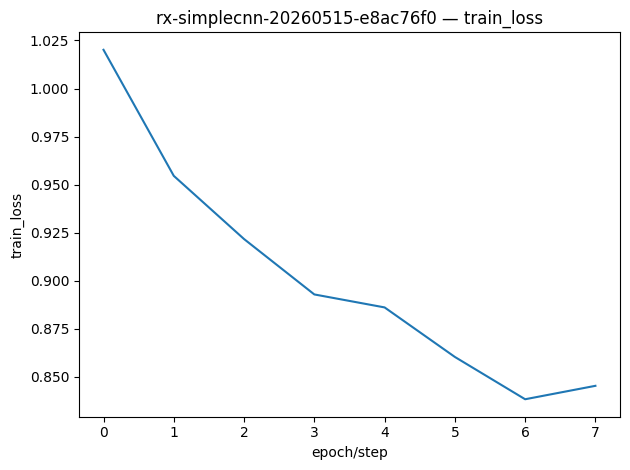

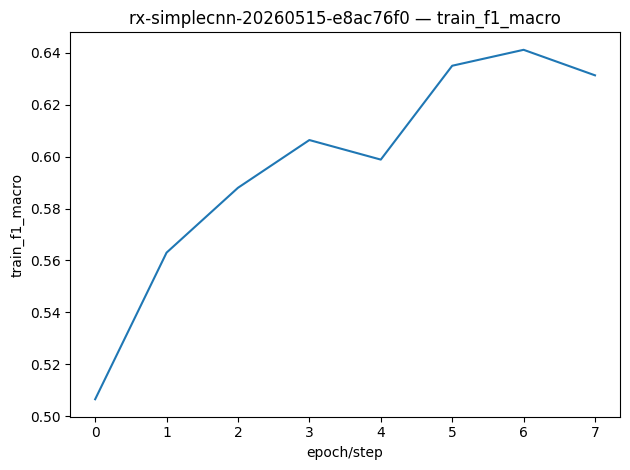

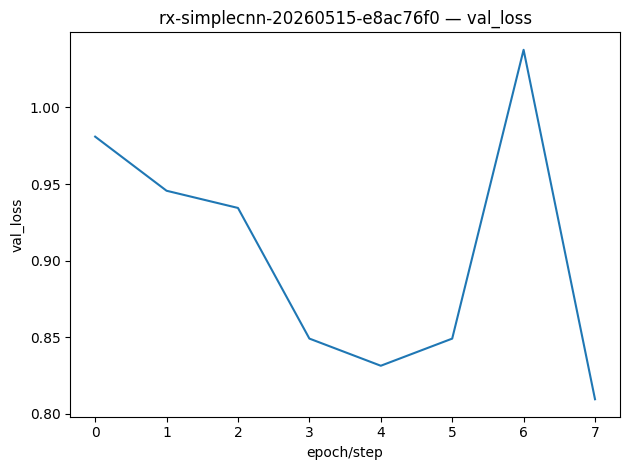

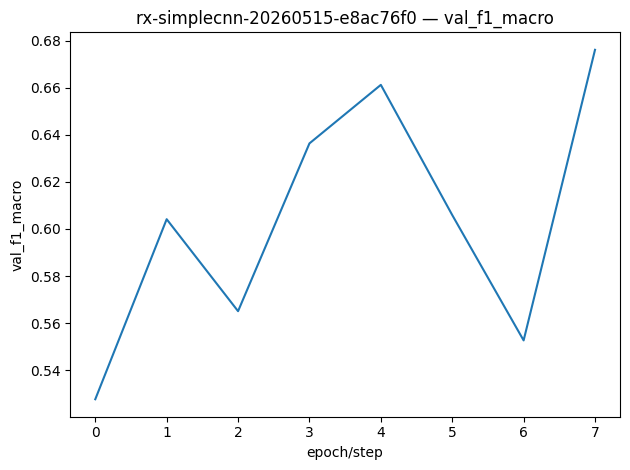

## 11. Modelo activo en inferencia

El servicio `ml-inference` carga el modelo indicado por la variable `ML_MODEL_PATH`.

Normalmente apunta a `/app/models/radiography/<VERSION>/model.pt`.

,campo,valor
0,ML_MODEL_PATH en .env,/app/models/radiography/rx-efficientnetb0-2026...
1,COVID_ALERT_THRESHOLD,0.80 por defecto
2,ML_DEVICE,cpu
3,models/radiography/current.txt,rx-efficientnetb0-20260515-2b92eec9


## 12. Pruebas opcionales contra `/predict`

Esta sección puede llamar al servicio real `ml-inference`.

Por defecto está desactivada. Cambia `RUN_API_CHECKS = True` si tienes Docker Compose levantado.

,clase_esperada_aproximada,ruta,existe
0,COVID-19,COVID-19_Radiography_Dataset\COVID\images\COVI...,True
1,Sana,COVID-19_Radiography_Dataset\Normal\images\Nor...,True
2,Neumonía viral,COVID-19_Radiography_Dataset\Viral Pneumonia\i...,True
3,Lung opacity agrupado como Neumonía,COVID-19_Radiography_Dataset\Lung_Opacity\imag...,True


`RUN_API_CHECKS = False`: no se llama al servicio real. Actívalo si Docker Compose está levantado.

...

### Comparar modelos

```powershell
docker compose run --rm ml-inference python -m training.compare_models `
  --models-root /app/models/radiography `
  --output /app/models/radiography/comparison
```

### Activar mejor modelo

```powershell
$best = "rx-efficientnetb0-20260515-2b92eec9"
$line = "ML_MODEL_PATH=/app/models/radiography/$best/model.pt"

if (Select-String -Path .env -Pattern "^ML_MODEL_PATH=" -Quiet) {
  (Get-Content .env) -replace "^ML_MODEL_PATH=.*", $line | Set-Content .env
} else {
  Add-Content .env $line
}

docker compose --env-file .env up -d --force-recreate ml-inference
docker compose exec ml-inference curl -s http://localhost:8001/healthz
```

## 14. Resumen para defensa

El módulo `ml-inference` demuestra la parte de Deep Learning del proyecto:

1. Usa un dataset público de radiografías.
2. Limpia correctamente los datos usando solo carpetas `images/`.
3. Mapea cuatro clases originales a tres clases exigidas por el reto.
4. Compara tres arquitecturas:
   - CNN simple;
   - ResNet18;
   - EfficientNet-B0.
5. Evalúa con métricas clínicas:
   - accuracy;
   - F1 macro;
   - recall COVID-19;
   - recall Neumonía;
   - matriz de confusión.
6. Genera análisis crítico por modelo.
7. Selecciona el mejor modelo por equilibrio clínico, no solo por accuracy.
8. Expone `/predict` mediante FastAPI.
9. Integra inferencia en dashboard.
10. Mantiene el sistema containerizado con Docker Compose.

La salida del modelo debe interpretarse como **apoyo a la decisión clínica**, no como diagnóstico automático.

In [2]:
from pathlib import Path
import ast
import json
import os
import subprocess
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPImage


# =============================================================================
# 0. Utilidades base
# =============================================================================

FENCE = "`" * 3


def md(text: str) -> None:
    """Renderiza Markdown desde una celda Python."""
    display(Markdown(textwrap.dedent(text).strip()))


def code_block(lang: str, text: str) -> None:
    """Renderiza bloques de código sin romper la celda Python."""
    display(Markdown(f"{FENCE}{lang}\n{textwrap.dedent(text).strip()}\n{FENCE}"))


def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto localizando docker-compose.yml."""
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "docker-compose.yml").exists():
            return candidate

    return start


ROOT = find_project_root()
print(f"ROOT = {ROOT}")


def read_json(path: Path, default=None):
    """Lee JSON de forma segura."""
    path = Path(path)

    if not path.exists():
        return default

    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(f"[error leyendo JSON] {path}: {exc}")
        return default


def read_text(path: Path, default: str = "") -> str:
    """Lee texto de forma segura."""
    path = Path(path)

    if not path.exists():
        return default

    try:
        return path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return default


def read_env(path: Path) -> dict:
    """Lee variables simples desde .env."""
    env = {}
    path = Path(path)

    if not path.exists():
        return env

    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        k, v = line.split("=", 1)
        env[k.strip()] = v.strip().strip('"').strip("'")

    return env


def run_cmd(cmd: str, timeout: int = 60) -> str:
    """Ejecuta un comando shell y devuelve stdout/stderr."""
    print(f"$ {cmd}")

    try:
        result = subprocess.run(
            cmd,
            shell=True,
            cwd=ROOT,
            text=True,
            capture_output=True,
            timeout=timeout,
        )

        if result.stdout:
            print(result.stdout)

        if result.stderr:
            print(result.stderr)

        print(f"exit_code={result.returncode}")
        return (result.stdout or "") + (result.stderr or "")

    except Exception as exc:
        print(f"[error] {exc}")
        return str(exc)


def file_size_mb(path: Path) -> float | None:
    try:
        return round(path.stat().st_size / (1024 * 1024), 3)
    except Exception:
        return None


def file_size_kb(path: Path) -> float | None:
    try:
        return round(path.stat().st_size / 1024, 2)
    except Exception:
        return None


def line_count(path: Path) -> int | None:
    try:
        return len(path.read_text(encoding="utf-8", errors="ignore").splitlines())
    except Exception:
        return None


def extract_docstring(path: Path) -> str:
    """Extrae docstring principal de un .py."""
    try:
        source = path.read_text(encoding="utf-8", errors="ignore")
        tree = ast.parse(source)
        doc = ast.get_docstring(tree) or ""
        return " ".join(doc.strip().split())
    except Exception:
        return ""


def extract_public_symbols(path: Path) -> list[str]:
    """Lista clases y funciones públicas de un .py."""
    try:
        source = path.read_text(encoding="utf-8", errors="ignore")
        tree = ast.parse(source)

        functions = []
        classes = []

        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                if not node.name.startswith("_"):
                    functions.append(node.name)

            if isinstance(node, ast.ClassDef):
                if not node.name.startswith("_"):
                    classes.append(node.name)

        out = [f"class {x}" for x in sorted(set(classes))]
        out += [f"def {x}" for x in sorted(set(functions))]
        return out

    except Exception:
        return []


ml_root = ROOT / "services" / "ml-inference"
app_root = ml_root / "app"
training_root = ml_root / "training"
models_root = ROOT / "models" / "radiography"
data_root = ROOT / "data" / "covid-subset"
raw_dataset_root = ROOT / "COVID-19_Radiography_Dataset"


# =============================================================================
# 1. Introducción
# =============================================================================

md("""
# 03 — ML Inference: clasificación de radiografías

Este notebook explica el módulo `services/ml-inference`, responsable de clasificar radiografías de tórax en tres clases:

- **Sana**
- **Neumonía**
- **COVID-19**

El objetivo no es solo ejecutar un modelo, sino demostrar un flujo completo de Deep Learning aplicado a imágenes médicas:

1. Preparar el dataset.
2. Limpiar rutas incorrectas y excluir `masks/`.
3. Definir arquitecturas.
4. Entrenar modelos.
5. Evaluar con métricas clínicas.
6. Analizar matriz de confusión.
7. Comparar CNN simple, ResNet18 y EfficientNet-B0.
8. Elegir un modelo por criterio clínico, no solo por accuracy.
9. Exponer inferencia mediante FastAPI.
10. Integrar el resultado en dashboard y arquitectura Docker.
""")


# =============================================================================
# 2. Estructura del módulo
# =============================================================================

md("""
## 1. Estructura de `services/ml-inference`

El módulo se divide en dos partes:

| Carpeta | Función |
|---|---|
| `app/` | Servicio FastAPI de inferencia. Carga el modelo y expone `/healthz` y `/predict`. |
| `training/` | Código offline para preparar datos, entrenar, evaluar, comparar modelos y generar análisis crítico. |

Esto separa claramente:

- **Entrenamiento**: pesado, offline, reproducible.
- **Inferencia**: ligera, online, servida por API.
""")

if not ml_root.exists():
    md(f"❌ No existe `{ml_root}`.")
else:
    tree_rows = []

    for path in sorted(ml_root.rglob("*")):
        if path.is_file():
            rel = str(path.relative_to(ml_root)).replace("\\", "/")
            tree_rows.append({
                "archivo": rel,
                "líneas": line_count(path),
                "tamaño_kb": file_size_kb(path),
                "elementos Python detectados": ", ".join(extract_public_symbols(path)[:10]) if path.suffix == ".py" else "",
            })

    display(pd.DataFrame(tree_rows))


# =============================================================================
# 3. Explicación archivo por archivo
# =============================================================================

md("""
## 2. Explicación archivo por archivo

Esta tabla resume para qué sirve cada archivo del módulo `ml-inference`.
""")

file_explanations = pd.DataFrame([
    {
        "archivo": "app/__init__.py",
        "tipo": "Servicio de inferencia",
        "función": "Marca `app/` como paquete Python.",
        "relación en el flujo": "Permite imports internos del servicio FastAPI.",
    },
    {
        "archivo": "app/app.py",
        "tipo": "API FastAPI",
        "función": "Define `/healthz`, `/predict` y `/`. Carga el modelo al arrancar mediante lifespan.",
        "relación en el flujo": "Recibe una imagen, llama al predictor y devuelve clase/probabilidades.",
    },
    {
        "archivo": "app/config.py",
        "tipo": "Configuración",
        "función": "Define `MODEL_PATH`, `ML_DEVICE`, `COVID_ALERT_THRESHOLD`, clases y normalización.",
        "relación en el flujo": "Controla qué modelo se carga, dispositivo usado y umbral de alerta COVID.",
    },
    {
        "archivo": "app/predictor.py",
        "tipo": "Inferencia",
        "función": "Carga el modelo PyTorch, transforma la imagen, calcula softmax y genera respuesta.",
        "relación en el flujo": "Es el núcleo de inferencia: imagen → tensor → modelo → probabilidades.",
    },
    {
        "archivo": "app/schemas.py",
        "tipo": "Contrato API",
        "función": "Define el esquema Pydantic de salida de `/predict`.",
        "relación en el flujo": "Garantiza que la respuesta tenga campos consistentes para API/dashboard.",
    },
    {
        "archivo": "training/prepare_data.py",
        "tipo": "Preparación de datos",
        "función": "Recoge imágenes desde carpetas `images/`, excluye `masks/`, balancea clases y genera train/val/test.",
        "relación en el flujo": "Produce `data/covid-subset/train.csv`, `val.csv`, `test.csv`, `metadata.json`.",
    },
    {
        "archivo": "training/dataset.py",
        "tipo": "Dataset PyTorch",
        "función": "Define `RadiographyDataset`, que lee rutas de CSV y devuelve imagen + etiqueta.",
        "relación en el flujo": "Alimenta el DataLoader durante entrenamiento y evaluación.",
    },
    {
        "archivo": "training/augment.py",
        "tipo": "Preprocesamiento",
        "función": "Define transformaciones de entrenamiento y evaluación: resize, crop, rotación, normalización ImageNet.",
        "relación en el flujo": "Convierte imágenes en tensores compatibles con los modelos.",
    },
    {
        "archivo": "training/model.py",
        "tipo": "Arquitecturas",
        "función": "Define `simple_cnn`, `resnet18` y `efficientnet_b0` con salida de 3 clases.",
        "relación en el flujo": "Permite comparar baseline CNN vs transfer learning.",
    },
    {
        "archivo": "training/train.py",
        "tipo": "Entrenamiento",
        "función": "Entrena modelos, guarda `model.pt`, `metadata.json` e histórico de entrenamiento.",
        "relación en el flujo": "Genera artefactos versionados `models/radiography/rx-*`.",
    },
    {
        "archivo": "training/evaluate.py",
        "tipo": "Evaluación",
        "función": "Evalúa un artefacto sobre test y genera `metrics.json` y `confusion_matrix.png`.",
        "relación en el flujo": "Produce evidencia numérica y visual para justificar el modelo.",
    },
    {
        "archivo": "training/critical_analysis.py",
        "tipo": "Interpretación clínica",
        "función": "Lee métricas y matriz de confusión, genera `critical_analysis.md`.",
        "relación en el flujo": "Explica impacto clínico de falsos negativos/falsos positivos.",
    },
    {
        "archivo": "training/compare_models.py",
        "tipo": "Comparación experimental",
        "función": "Compara todos los modelos `rx-*` y genera `comparison.csv`, `comparison.md`, `comparison.json`.",
        "relación en el flujo": "Permite seleccionar modelo por F1 macro, recall COVID y recall neumonía.",
    },
    {
        "archivo": "training/requirements-training.txt",
        "tipo": "Dependencias training",
        "función": "Dependencias para entrenamiento/evaluación: torch, torchvision, pandas, sklearn, matplotlib.",
        "relación en el flujo": "Permite reproducir entrenamiento dentro de Docker.",
    },
    {
        "archivo": "requirements.txt",
        "tipo": "Dependencias inferencia",
        "función": "Dependencias del servicio FastAPI: torch, torchvision, pillow, fastapi, uvicorn.",
        "relación en el flujo": "Permite desplegar `/predict` en Docker Compose.",
    },
    {
        "archivo": "README.md",
        "tipo": "Documentación",
        "función": "Explica dataset, modelos, entrenamiento, evaluación, integración y limitaciones.",
        "relación en el flujo": "Sirve para defensa y reproducibilidad.",
    },
])

display(file_explanations)


# =============================================================================
# 4. Flujo imagen -> predicción
# =============================================================================

md("""
## 3. Flujo completo: de una imagen a una clasificación

El módulo no “sabe” la enfermedad de forma directa. Lo que hace es transformar una imagen en una representación numérica y pasarla por una red neuronal entrenada.
""")

flow_df = pd.DataFrame([
    {
        "paso": 1,
        "etapa": "Entrada",
        "qué ocurre": "El usuario sube una radiografía PNG/JPG desde dashboard o con curl.",
        "archivo implicado": "app/app.py",
        "salida": "Bytes de imagen.",
    },
    {
        "paso": 2,
        "etapa": "Validación de archivo",
        "qué ocurre": "FastAPI comprueba que el content-type sea imagen JPEG/PNG y que el fichero no esté vacío.",
        "archivo implicado": "app/app.py",
        "salida": "Imagen aceptada o error 400/422.",
    },
    {
        "paso": 3,
        "etapa": "Carga PIL",
        "qué ocurre": "La imagen se abre con PIL y se convierte a RGB.",
        "archivo implicado": "app/predictor.py",
        "salida": "Objeto imagen RGB.",
    },
    {
        "paso": 4,
        "etapa": "Preprocesamiento",
        "qué ocurre": "Resize a 224x224, tensorización y normalización con media/desviación ImageNet.",
        "archivo implicado": "app/predictor.py + app/config.py",
        "salida": "Tensor `[1, 3, 224, 224]`.",
    },
    {
        "paso": 5,
        "etapa": "Inferencia",
        "qué ocurre": "El tensor entra al modelo PyTorch activo (`model.pt`).",
        "archivo implicado": "app/predictor.py",
        "salida": "Logits de 3 clases.",
    },
    {
        "paso": 6,
        "etapa": "Softmax",
        "qué ocurre": "Se convierten logits en probabilidades.",
        "archivo implicado": "app/predictor.py",
        "salida": "Probabilidades para Sana, Neumonía y COVID-19.",
    },
    {
        "paso": 7,
        "etapa": "Decisión",
        "qué ocurre": "Se selecciona la clase con mayor probabilidad.",
        "archivo implicado": "app/predictor.py",
        "salida": "`predicted_class`.",
    },
    {
        "paso": 8,
        "etapa": "Flags clínicos",
        "qué ocurre": "Se calcula `low_confidence` y `triggers_covid_alert`.",
        "archivo implicado": "app/predictor.py + app/config.py",
        "salida": "Avisos para dashboard/API.",
    },
    {
        "paso": 9,
        "etapa": "Respuesta API",
        "qué ocurre": "FastAPI devuelve JSON con clase, probabilidades, versión e inferencia.",
        "archivo implicado": "app/schemas.py",
        "salida": "Respuesta consumible por dashboard.",
    },
])

display(flow_df)

code_block("text", """
Imagen radiografía
        |
        v
FastAPI /predict
        |
        v
Validación tipo fichero
        |
        v
PIL.Image.open(...).convert("RGB")
        |
        v
Resize 224x224
        |
        v
ToTensor + Normalize(ImageNet)
        |
        v
Modelo PyTorch activo
        |
        v
Logits
        |
        v
Softmax
        |
        v
Probabilidades:
  - Sana
  - Neumonía
  - COVID-19
        |
        v
Respuesta JSON:
  - predicted_class
  - probabilities
  - model_version
  - inference_time_ms
  - low_confidence
  - triggers_covid_alert
""")


# =============================================================================
# 5. Dataset y mapeo de clases
# =============================================================================

md("""
## 4. Dataset y clases

El dataset original tiene cuatro carpetas principales:

- `Normal`
- `Viral Pneumonia`
- `Lung_Opacity`
- `COVID`

Pero el enunciado exige clasificación triple. Por eso se aplica este mapeo:
""")

mapping_df = pd.DataFrame([
    {"clase_original": "Normal", "clase_final": "Sana", "motivo": "Radiografía sin patología detectable."},
    {"clase_original": "Viral Pneumonia", "clase_final": "Neumonía", "motivo": "Neumonía viral estándar."},
    {"clase_original": "Lung_Opacity", "clase_final": "Neumonía", "motivo": "Se agrupa por requisito académico de 3 clases."},
    {"clase_original": "COVID", "clase_final": "COVID-19", "motivo": "Patrones radiológicos asociados a COVID-19."},
])

display(mapping_df)

md("""
### Limpieza importante realizada

Durante el desarrollo se detectó que el dataset también contenía carpetas `masks/`.

Las máscaras **no son radiografías originales**, sino segmentaciones binarias de pulmones. Si se entrenara con `masks/`, el modelo aprendería patrones artificiales y la evaluación quedaría contaminada.

Por eso `prepare_data.py` se corrigió para leer solo carpetas `images/` y excluir `masks/`.
""")

code_block("text", """
Se usa:
COVID-19_Radiography_Dataset/<clase>/images/

Se excluye:
COVID-19_Radiography_Dataset/<clase>/masks/
""")

metadata_path = data_root / "metadata.json"

if metadata_path.exists():
    metadata = read_json(metadata_path, {})
    md("### Metadata del subset generado")
    display(pd.DataFrame([metadata]))

    counts = metadata.get("counts", {})
    if counts:
        md("### Distribución final por clase")
        display(pd.DataFrame([{"clase": k, "n_imágenes": v} for k, v in counts.items()]))

        plt.figure()
        pd.Series(counts).sort_index().plot(kind="bar")
        plt.title("Distribución de clases finales")
        plt.ylabel("n imágenes")
        plt.xlabel("clase")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

else:
    md("⚠️ No se encontró `data/covid-subset/metadata.json`. Ejecuta `training.prepare_data` para generarlo.")


# =============================================================================
# 6. Splits train / val / test
# =============================================================================

md("""
## 5. Splits de entrenamiento, validación y test

El entrenamiento usa tres particiones:

| Split | Para qué sirve |
|---|---|
| `train.csv` | Ajustar pesos del modelo |
| `val.csv` | Seleccionar mejor modelo durante entrenamiento |
| `test.csv` | Evaluar rendimiento final no visto |
""")

split_rows = []

for split in ["train", "val", "test"]:
    csv_path = data_root / f"{split}.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path)

        masks_count = int(df["filepath"].str.contains("masks", case=False, na=False).sum()) if "filepath" in df.columns else None

        if "filepath" in df.columns:
            normalized_paths = df["filepath"].astype(str).str.replace("\\", "/", regex=False)
            images_count = int(normalized_paths.str.contains("/images/", case=False, na=False).sum())
        else:
            images_count = None

        split_rows.append({
            "split": split,
            "filas": len(df),
            "masks_en_rutas": masks_count,
            "images_en_rutas": images_count,
        })

        md(f"### Distribución `{split}.csv`")
        display(df["class_target"].value_counts().rename_axis("clase").reset_index(name="n"))

if split_rows:
    display(pd.DataFrame(split_rows))
else:
    md("⚠️ No se han encontrado CSVs en `data/covid-subset/`.")


# =============================================================================
# 7. Arquitecturas comparadas
# =============================================================================

md("""
## 6. Arquitecturas comparadas

Se compararon tres modelos para justificar la elección técnica.
""")

architectures_df = pd.DataFrame([
    {
        "modelo": "simple_cnn",
        "tipo": "CNN entrenada desde cero",
        "ventaja": "Simple, rápida, sirve como baseline.",
        "limitación": "Menor capacidad de representación; más débil en imágenes médicas complejas.",
        "papel en el experimento": "Punto mínimo de comparación.",
    },
    {
        "modelo": "resnet18",
        "tipo": "Transfer learning",
        "ventaja": "Arquitectura clásica, robusta, fácil de justificar.",
        "limitación": "Más pesada que CNN simple; puede requerir más CPU.",
        "papel en el experimento": "Comparar baseline con preentrenamiento estándar.",
    },
    {
        "modelo": "efficientnet_b0",
        "tipo": "Transfer learning eficiente",
        "ventaja": "Buen equilibrio entre rendimiento, tamaño y coste.",
        "limitación": "Más compleja que ResNet18 de explicar desde cero.",
        "papel en el experimento": "Modelo candidato final.",
    },
])

display(architectures_df)

md("""
### Por qué transfer learning

En imagen médica, entrenar una red profunda desde cero suele requerir muchísimas imágenes. En este proyecto usamos modelos preentrenados en ImageNet porque:

- convergen antes;
- reducen riesgo de sobreajuste;
- necesitan menos datos;
- dan mejor punto de partida;
- son viables dentro de Docker Compose.

La cabeza final se sustituye para producir tres clases.
""")


# =============================================================================
# 8. Artefactos generados
# =============================================================================

md("""
## 7. Artefactos de modelos generados

Cada entrenamiento genera una carpeta versionada en `models/radiography/rx-*`.

Cada carpeta debe contener:

- `model.pt`
- `metadata.json`
- `history.csv`
- `history.json`
- `metrics.json`
- `confusion_matrix.png`
- `critical_analysis.md`
""")

artifact_rows = []

if models_root.exists():
    for artifact_dir in sorted(models_root.iterdir()):
        if not artifact_dir.is_dir() or not artifact_dir.name.startswith("rx-"):
            continue

        metadata = read_json(artifact_dir / "metadata.json", {})
        metrics = read_json(artifact_dir / "metrics.json", {})

        artifact_rows.append({
            "version": artifact_dir.name,
            "backbone": metadata.get("backbone") or metadata.get("config", {}).get("backbone"),
            "accuracy": metrics.get("accuracy"),
            "f1_macro": metrics.get("f1_macro"),
            "recall_covid": metrics.get("recall_covid"),
            "recall_neumonia": metrics.get("recall_neumonia"),
            "best_val_f1_macro": metadata.get("best_val_f1_macro"),
            "model.pt_MB": file_size_mb(artifact_dir / "model.pt") if (artifact_dir / "model.pt").exists() else None,
            "metrics.json": (artifact_dir / "metrics.json").exists(),
            "confusion_matrix.png": (artifact_dir / "confusion_matrix.png").exists(),
            "critical_analysis.md": (artifact_dir / "critical_analysis.md").exists(),
            "ruta": str(artifact_dir.relative_to(ROOT)),
        })

if artifact_rows:
    artifacts_df = pd.DataFrame(artifact_rows)
    display(artifacts_df.sort_values("f1_macro", ascending=False, na_position="last"))
else:
    md("⚠️ No se encontraron artefactos `rx-*` en `models/radiography/`.")


# =============================================================================
# 9. Comparación final de modelos
# =============================================================================

md("""
## 8. Comparación final de modelos

La comparación final se genera con `training.compare_models`.

El criterio de selección no es solo `accuracy`.

En contexto sanitario se prioriza:

- `f1_macro`;
- `recall_covid`;
- `recall_neumonia`;
- matriz de confusión;
- impacto clínico de falsos negativos.
""")

comparison_csv = models_root / "comparison" / "comparison.csv"
comparison_md = models_root / "comparison" / "comparison.md"

if comparison_csv.exists():
    comparison_df = pd.read_csv(comparison_csv)
    display(comparison_df)

    for metric in ["accuracy", "f1_macro", "recall_covid", "recall_neumonia"]:
        if metric in comparison_df.columns:
            plt.figure()
            comparison_df.set_index("backbone")[metric].plot(kind="bar")
            plt.title(f"Comparación de modelos — {metric}")
            plt.ylabel(metric)
            plt.xlabel("backbone")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()

    best = comparison_df.sort_values(
        by=["f1_macro", "recall_covid", "recall_neumonia"],
        ascending=False,
        na_position="last",
    ).iloc[0]

    md(f"""
### Modelo seleccionado

El modelo seleccionado por equilibrio clínico es:

- **Versión:** `{best.get("version")}`
- **Backbone:** `{best.get("backbone")}`
- **Accuracy:** `{float(best.get("accuracy")):.4f}`
- **F1 macro:** `{float(best.get("f1_macro")):.4f}`
- **Recall COVID-19:** `{float(best.get("recall_covid")):.4f}`
- **Recall Neumonía:** `{float(best.get("recall_neumonia")):.4f}`

Se selecciona porque combina buen rendimiento global con alta sensibilidad en las clases clínicamente más relevantes.
""")

else:
    md("⚠️ No se encontró `models/radiography/comparison/comparison.csv`.")

if comparison_md.exists():
    md("### Informe `comparison.md`")
    display(Markdown(read_text(comparison_md)))


# =============================================================================
# 10. Matrices de confusión y análisis crítico
# =============================================================================

md("""
## 9. Matrices de confusión y análisis crítico

Para cada modelo se muestran:

1. Métricas principales.
2. Matriz de confusión numérica.
3. Matriz de confusión visual.
4. Análisis crítico generado.

Esto permite ver no solo cuánto acierta, sino **en qué se equivoca**.
""")


def show_model_report(artifact_dir: Path) -> None:
    metadata = read_json(artifact_dir / "metadata.json", {})
    metrics = read_json(artifact_dir / "metrics.json", {})
    critical = read_text(artifact_dir / "critical_analysis.md")
    cm_path = artifact_dir / "confusion_matrix.png"

    backbone = metadata.get("backbone") or metadata.get("config", {}).get("backbone", "desconocido")

    md(f"""
---

### Modelo `{artifact_dir.name}`

**Backbone:** `{backbone}`
""")

    metric_keys = ["accuracy", "f1_macro", "recall_covid", "recall_neumonia"]
    metric_rows = [{"métrica": k, "valor": metrics.get(k)} for k in metric_keys if k in metrics]

    if metric_rows:
        display(pd.DataFrame(metric_rows))

    if isinstance(metrics.get("per_class"), dict):
        md("#### Métricas por clase")
        display(pd.DataFrame(metrics["per_class"]).T)

    cm = metrics.get("confusion_matrix")

    if isinstance(cm, list):
        labels = ["Sana", "Neumonía", "COVID-19"]

        if len(cm) != len(labels):
            labels = [f"Clase {i}" for i in range(len(cm))]

        cm_df = pd.DataFrame(
            cm,
            index=[f"Real: {x}" for x in labels],
            columns=[f"Pred: {x}" for x in labels],
        )

        md("#### Matriz de confusión numérica")
        display(cm_df)

        errors = []
        for i, real in enumerate(labels):
            for j, pred in enumerate(labels):
                if i != j:
                    errors.append({
                        "clase_real": real,
                        "clase_predicha": pred,
                        "casos": cm[i][j],
                    })

        md("#### Errores principales")
        display(pd.DataFrame(errors).sort_values("casos", ascending=False).head(10))

    if cm_path.exists():
        md("#### Matriz de confusión visual")
        display(IPImage(filename=str(cm_path)))

    if critical:
        md("#### Análisis crítico generado")
        display(Markdown(critical))


if models_root.exists():
    for artifact_dir in sorted(models_root.iterdir()):
        if artifact_dir.is_dir() and artifact_dir.name.startswith("rx-"):
            show_model_report(artifact_dir)


# =============================================================================
# 11. Históricos de entrenamiento
# =============================================================================

md("""
## 10. Históricos de entrenamiento

Si existe `history.csv`, se muestran las curvas de entrenamiento y validación.
""")

if models_root.exists():
    for artifact_dir in sorted(models_root.iterdir()):
        history_path = artifact_dir / "history.csv"

        if artifact_dir.is_dir() and artifact_dir.name.startswith("rx-") and history_path.exists():
            hist = pd.read_csv(history_path)

            md(f"### Histórico `{artifact_dir.name}`")
            display(hist.head())

            numeric_cols = [
                c for c in hist.columns
                if c not in ["phase", "backbone"] and pd.api.types.is_numeric_dtype(hist[c])
            ]

            for col in numeric_cols:
                if "f1" in col.lower() or "loss" in col.lower():
                    plt.figure()
                    hist[col].plot()
                    plt.title(f"{artifact_dir.name} — {col}")
                    plt.xlabel("epoch/step")
                    plt.ylabel(col)
                    plt.tight_layout()
                    plt.show()


# =============================================================================
# 12. Configuración activa de inferencia
# =============================================================================

md("""
## 11. Modelo activo en inferencia

El servicio `ml-inference` carga el modelo indicado por la variable `ML_MODEL_PATH`.

Normalmente apunta a `/app/models/radiography/<VERSION>/model.pt`.
""")

env = read_env(ROOT / ".env")
ml_model_path = env.get("ML_MODEL_PATH", "")

active_rows = [
    {"campo": "ML_MODEL_PATH en .env", "valor": ml_model_path or "no configurado"},
    {"campo": "COVID_ALERT_THRESHOLD", "valor": env.get("COVID_ALERT_THRESHOLD", "0.80 por defecto")},
    {"campo": "ML_DEVICE", "valor": env.get("ML_DEVICE", "cpu por defecto")},
]

current_txt = models_root / "current.txt"

if current_txt.exists():
    active_rows.append({
        "campo": "models/radiography/current.txt",
        "valor": read_text(current_txt).strip(),
    })

display(pd.DataFrame(active_rows))


# =============================================================================
# 13. Pruebas opcionales contra la API real
# =============================================================================

md("""
## 12. Pruebas opcionales contra `/predict`

Esta sección puede llamar al servicio real `ml-inference`.

Por defecto está desactivada. Cambia `RUN_API_CHECKS = True` si tienes Docker Compose levantado.
""")

RUN_API_CHECKS = False
ML_INFERENCE_URL_HOST = "http://localhost:8001"

sample_images = [
    ("COVID-19", raw_dataset_root / "COVID" / "images" / "COVID-1.png"),
    ("Sana", raw_dataset_root / "Normal" / "images" / "Normal-1.png"),
    ("Neumonía viral", raw_dataset_root / "Viral Pneumonia" / "images" / "Viral Pneumonia-1.png"),
    ("Lung opacity agrupado como Neumonía", raw_dataset_root / "Lung_Opacity" / "images" / "Lung_Opacity-1.png"),
]

sample_rows = []

for label, path in sample_images:
    sample_rows.append({
        "clase_esperada_aproximada": label,
        "ruta": str(path.relative_to(ROOT)) if path.exists() else str(path),
        "existe": path.exists(),
    })

display(pd.DataFrame(sample_rows))

if RUN_API_CHECKS:
    import requests

    try:
        health = requests.get(f"{ML_INFERENCE_URL_HOST}/healthz", timeout=10)
        print("Health:", health.status_code, health.text)
    except Exception as exc:
        print("No se pudo consultar /healthz:", exc)

    prediction_rows = []

    for expected_label, image_path in sample_images:
        if not image_path.exists():
            prediction_rows.append({
                "imagen": expected_label,
                "error": f"No existe {image_path}",
            })
            continue

        try:
            with open(image_path, "rb") as f:
                response = requests.post(
                    f"{ML_INFERENCE_URL_HOST}/predict",
                    files={"file": (image_path.name, f, "image/png")},
                    timeout=60,
                )

            if response.status_code != 200:
                prediction_rows.append({
                    "imagen": expected_label,
                    "status_code": response.status_code,
                    "error": response.text[:300],
                })
                continue

            result = response.json()
            probs = result.get("probabilities", {})

            prediction_rows.append({
                "imagen": expected_label,
                "predicted_class": result.get("predicted_class"),
                "p_sana": probs.get("Sana"),
                "p_neumonia": probs.get("Neumonía"),
                "p_covid": probs.get("COVID-19"),
                "low_confidence": result.get("low_confidence"),
                "triggers_covid_alert": result.get("triggers_covid_alert"),
                "model_version": result.get("model_version"),
                "inference_time_ms": result.get("inference_time_ms"),
            })

        except Exception as exc:
            prediction_rows.append({
                "imagen": expected_label,
                "error": str(exc),
            })

    display(pd.DataFrame(prediction_rows))

else:
    md("`RUN_API_CHECKS = False`: no se llama al servicio real. Actívalo si Docker Compose está levantado.")


# =============================================================================
# 14. Comandos reproducibles
# =============================================================================

md("""
## 13. Comandos reproducibles

### Preparar dataset limpio, solo `images/`
""")

code_block("powershell", """
docker compose run --rm ml-inference python -m training.prepare_data `
  --raw-dir /app/COVID-19_Radiography_Dataset `
  --output-dir /app/data/covid-subset `
  --limit-per-class 1000 `
  --seed 42
""")

md("### Entrenar CNN simple")

code_block("powershell", """
docker compose run --rm ml-inference python -m training.train `
  --backbone simple_cnn `
  --train-csv /app/data/covid-subset/train.csv `
  --val-csv /app/data/covid-subset/val.csv `
  --models-root /app/models/radiography `
  --batch-size 32 `
  --warmup-epochs 0 `
  --max-epochs 8 `
  --num-workers 0 `
  --seed 42
""")

md("### Entrenar ResNet18")

code_block("powershell", """
docker compose run --rm ml-inference python -m training.train `
  --backbone resnet18 `
  --train-csv /app/data/covid-subset/train.csv `
  --val-csv /app/data/covid-subset/val.csv `
  --models-root /app/models/radiography `
  --batch-size 16 `
  --warmup-epochs 2 `
  --max-epochs 8 `
  --num-workers 0 `
  --seed 42
""")

md("### Entrenar EfficientNet-B0")

code_block("powershell", """
docker compose run --rm ml-inference python -m training.train `
  --backbone efficientnet_b0 `
  --train-csv /app/data/covid-subset/train.csv `
  --val-csv /app/data/covid-subset/val.csv `
  --models-root /app/models/radiography `
  --batch-size 16 `
  --warmup-epochs 2 `
  --max-epochs 8 `
  --num-workers 0 `
  --seed 42
""")

md("### Evaluar y generar análisis crítico")

code_block("powershell", """
Get-ChildItem .\\models\\radiography -Directory | Where-Object { $_.Name -like "rx-*" } | ForEach-Object {
  $v = $_.Name

  docker compose run --rm ml-inference python -m training.evaluate `
    --artifact-dir "/app/models/radiography/$v" `
    --test-csv /app/data/covid-subset/test.csv `
    --batch-size 16 `
    --num-workers 0

  docker compose run --rm ml-inference python -m training.critical_analysis `
    --artifact-dir "/app/models/radiography/$v"
}
""")

md("### Comparar modelos")

code_block("powershell", """
docker compose run --rm ml-inference python -m training.compare_models `
  --models-root /app/models/radiography `
  --output /app/models/radiography/comparison
""")

md("### Activar mejor modelo")

code_block("powershell", """
$best = "rx-efficientnetb0-20260515-2b92eec9"
$line = "ML_MODEL_PATH=/app/models/radiography/$best/model.pt"

if (Select-String -Path .env -Pattern "^ML_MODEL_PATH=" -Quiet) {
  (Get-Content .env) -replace "^ML_MODEL_PATH=.*", $line | Set-Content .env
} else {
  Add-Content .env $line
}

docker compose --env-file .env up -d --force-recreate ml-inference
docker compose exec ml-inference curl -s http://localhost:8001/healthz
""")


# =============================================================================
# 15. Resumen para defensa
# =============================================================================

md("""
## 14. Resumen para defensa

El módulo `ml-inference` demuestra la parte de Deep Learning del proyecto:

1. Usa un dataset público de radiografías.
2. Limpia correctamente los datos usando solo carpetas `images/`.
3. Mapea cuatro clases originales a tres clases exigidas por el reto.
4. Compara tres arquitecturas:
   - CNN simple;
   - ResNet18;
   - EfficientNet-B0.
5. Evalúa con métricas clínicas:
   - accuracy;
   - F1 macro;
   - recall COVID-19;
   - recall Neumonía;
   - matriz de confusión.
6. Genera análisis crítico por modelo.
7. Selecciona el mejor modelo por equilibrio clínico, no solo por accuracy.
8. Expone `/predict` mediante FastAPI.
9. Integra inferencia en dashboard.
10. Mantiene el sistema containerizado con Docker Compose.

La salida del modelo debe interpretarse como **apoyo a la decisión clínica**, no como diagnóstico automático.
""")

## 1. Dataset y clases

Dataset local:

```text
COVID-19_Radiography_Dataset/
├── COVID/images/
├── Normal/images/
├── Viral Pneumonia/images/
└── Lung_Opacity/images/
```

Mapeo final:

| Origen | Clase final |
|---|---|
| `Normal` | `Sana` |
| `Viral Pneumonia` | `Neumonía` |
| `Lung_Opacity` | `Neumonía` |
| `COVID` | `COVID-19` |

La versión corregida de `prepare_data.py` usa solo `images/` y excluye `masks/`.

In [3]:
subset_dir = ROOT / "data/covid-subset"
metadata = read_json(subset_dir/"metadata.json", default={}) or {}
metadata


{'seed': 42,
 'limit_per_class': 1000,
 'counts_available': {'Sana': 10192, 'Neumonía': 7357, 'COVID-19': 3616},
 'counts_used': {'Sana': 1000, 'Neumonía': 1000, 'COVID-19': 1000},
 'counts_final': {'Sana': 1000, 'Neumonía': 1000, 'COVID-19': 1000},
 'splits': {'train': 2099, 'val': 451, 'test': 450},
 'class_mapping': {'Normal': 'Sana',
  'Viral Pneumonia': 'Neumonía',
  'Lung_Opacity': 'Neumonía',
  'COVID': 'COVID-19'},
 'note': 'Solo se usan imágenes dentro de carpetas images/. Se excluyen masks/.'}

In [4]:
# Cargar splits si existen
splits = {}
for split in ["train", "val", "test"]:
    path = subset_dir / f"{split}.csv"
    if path.exists():
        splits[split] = pd.read_csv(path)
        print(split, splits[split].shape)
    else:
        print(f"[missing] {path}")


train (2099, 3)
val (451, 3)
test (450, 3)


In [5]:
# Comprobar que no hay masks/ en los CSV
mask_rows = []
for split, df in splits.items():
    count = df["filepath"].astype(str).str.contains("/masks/|\\\\masks\\\\", regex=True).sum()
    mask_rows.append({"split": split, "filas_con_masks": int(count), "filas": len(df)})
pd.DataFrame(mask_rows)


,split,filas_con_masks,filas
0,train,0,2099
1,val,0,451
2,test,0,450


In [6]:
# Distribución por clase y split
rows = []
for split, df in splits.items():
    for cls, count in df["class_target"].value_counts().items():
        rows.append({"split": split, "class_target": cls, "count": count})
class_dist = pd.DataFrame(rows)
class_dist


,split,class_target,count
0,train,Neumonía,700
1,train,COVID-19,700
2,train,Sana,699
3,val,Sana,151
4,val,Neumonía,150
5,val,COVID-19,150
6,test,COVID-19,150
7,test,Sana,150
8,test,Neumonía,150


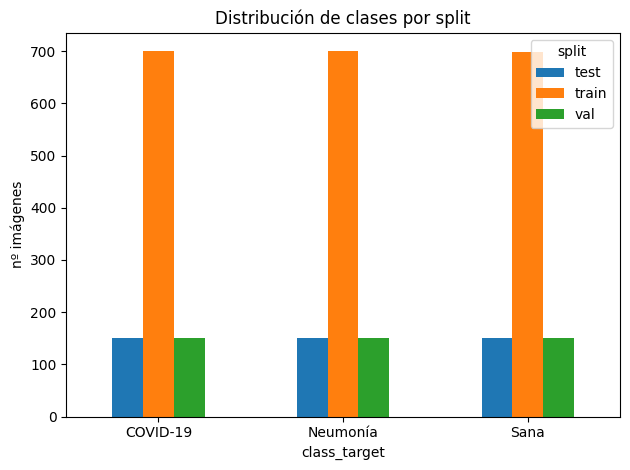

In [7]:
if not class_dist.empty:
    pivot = class_dist.pivot(index="class_target", columns="split", values="count").fillna(0)
    ax = pivot.plot(kind="bar")
    ax.set_title("Distribución de clases por split")
    ax.set_ylabel("nº imágenes")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 2. Visualización de ejemplos

Se muestran ejemplos por clase desde el CSV de entrenamiento. Si el dataset no está disponible localmente, esta celda simplemente avisará.

In [8]:
from PIL import Image

if "train" in splits:
    train_df = splits["train"]
    for cls in sorted(train_df["class_target"].unique()):
        sample = train_df[train_df["class_target"] == cls].iloc[0]
        path = Path(sample["filepath"])
        # La ruta dentro del CSV suele ser /app/..., la convertimos a ruta local del repo si hace falta.
        local_path = path
        if str(path).startswith("/app/"):
            local_path = ROOT / str(path).replace("/app/", "")
        print(cls, local_path)
        if local_path.exists():
            img = Image.open(local_path)
            plt.figure(figsize=(4, 4))
            plt.imshow(img, cmap="gray")
            plt.title(f"{cls} — {sample['class_original']}")
            plt.axis("off")
            plt.show()
        else:
            print("No existe localmente:", local_path)


COVID-19 \app\COVID-19_Radiography_Dataset\COVID\images\COVID-3099.png
No existe localmente: \app\COVID-19_Radiography_Dataset\COVID\images\COVID-3099.png
Neumonía \app\COVID-19_Radiography_Dataset\Lung_Opacity\images\Lung_Opacity-2701.png
No existe localmente: \app\COVID-19_Radiography_Dataset\Lung_Opacity\images\Lung_Opacity-2701.png
Sana \app\COVID-19_Radiography_Dataset\Normal\images\Normal-8463.png
No existe localmente: \app\COVID-19_Radiography_Dataset\Normal\images\Normal-8463.png


## 3. Preprocesamiento

Entrenamiento:

- resize a 256x256;
- `RandomResizedCrop(224)`;
- flip horizontal;
- rotación leve;
- ajuste leve de brillo/contraste;
- normalización ImageNet.

Validación/test/inferencia:

- resize directo a 224x224;
- tensor;
- normalización ImageNet.

No se aplican aumentos agresivos porque podrían alterar patrones radiológicos.

## 4. Modelos comparados

| Modelo | Tipo | Papel experimental |
|---|---|---|
| `simple_cnn` | CNN desde cero | Baseline. Sirve para medir cuánto aporta transfer learning. |
| `resnet18` | Transfer learning | Arquitectura clásica y robusta. |
| `efficientnet_b0` | Transfer learning eficiente | Mejor equilibrio coste/rendimiento. |

La selección final no se hace solo por accuracy, sino por comportamiento clínico: F1 macro, recall COVID y recall Neumonía.

=== Comparación CNN simple vs ResNet18 vs EfficientNet-B0 ===
comparison.csv existe: True
comparison.md existe: True


,version,backbone,accuracy,f1_macro,recall_covid,recall_neumonia,best_val_f1_macro,test_rows,artifact_dir
0,rx-efficientnetb0-20260515-2b92eec9,efficientnet_b0,0.960000,0.960079,0.980000,0.933333,0.888084,450,/app/models/radiography/rx-efficientnetb0-2026...
1,rx-resnet18-20260515-d397f8e5,resnet18,0.893333,0.892919,0.966667,0.833333,0.892065,450,/app/models/radiography/rx-resnet18-20260515-d...
2,rx-simplecnn-20260515-e8ac76f0,simple_cnn,0.702222,0.701260,0.700000,0.773333,0.676096,450,/app/models/radiography/rx-simplecnn-20260515-...


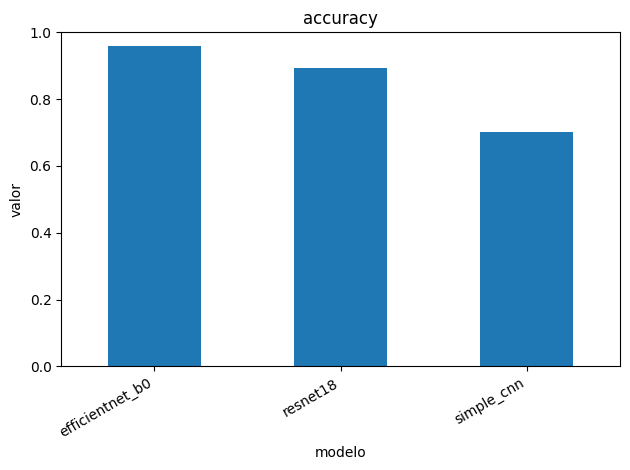

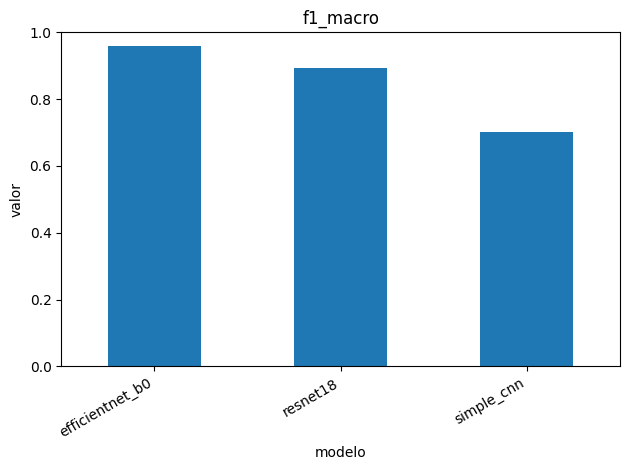

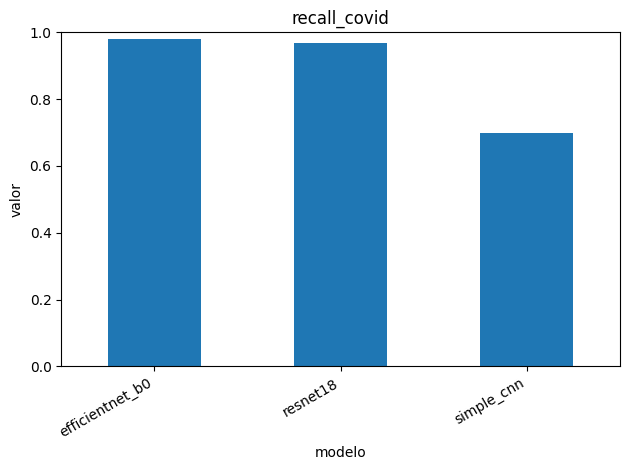

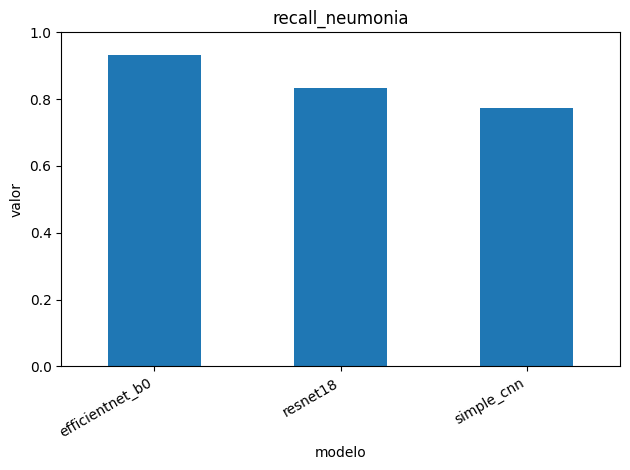


Modelo seleccionado:
Versión: rx-efficientnetb0-20260515-2b92eec9
Backbone: efficientnet_b0
Accuracy: 0.9600
F1 macro: 0.9601
Recall COVID: 0.9800
Recall Neumonía: 0.9333

comparison.md:
# Comparación de modelos — radiografías

| Ranking | Versión | Backbone | Accuracy | F1 macro | Recall COVID | Recall Neumonía |
|---:|---|---|---:|---:|---:|---:|
| 1 | `rx-efficientnetb0-20260515-2b92eec9` | `efficientnet_b0` | 0.9600 | 0.9601 | 0.9800 | 0.9333 |
| 2 | `rx-resnet18-20260515-d397f8e5` | `resnet18` | 0.8933 | 0.8929 | 0.9667 | 0.8333 |
| 3 | `rx-simplecnn-20260515-e8ac76f0` | `simple_cnn` | 0.7022 | 0.7013 | 0.7000 | 0.7733 |

## Criterio de selección

El modelo no se selecciona solo por accuracy. En contexto hospitalario se priorizan F1 macro y recall de COVID-19/Neumonía para reducir falsos negativos clínicamente relevantes.


In [9]:
comparison_path = ROOT / "models/radiography/comparison/comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
else:
    comparison = pd.DataFrame([
        {"version": "rx-efficientnetb0-20260515-2b92eec9", "backbone": "efficientnet_b0", "accuracy": 0.9600, "f1_macro": 0.9601, "recall_covid": 0.9800, "recall_neumonia": 0.9333},
        {"version": "rx-resnet18-20260515-d397f8e5", "backbone": "resnet18", "accuracy": 0.8933, "f1_macro": 0.8929, "recall_covid": 0.9667, "recall_neumonia": 0.8333},
        {"version": "rx-simplecnn-20260515-e8ac76f0", "backbone": "simple_cnn", "accuracy": 0.7022, "f1_macro": 0.7013, "recall_covid": 0.7000, "recall_neumonia": 0.7733},
    ])
comparison

print("=== Comparación CNN simple vs ResNet18 vs EfficientNet-B0 ===")

comparison_csv = ROOT / "models" / "radiography" / "comparison" / "comparison.csv"
comparison_md = ROOT / "models" / "radiography" / "comparison" / "comparison.md"

print(f"comparison.csv existe: {comparison_csv.exists()}")
print(f"comparison.md existe: {comparison_md.exists()}")

if comparison_csv.exists():
    comparison = pd.read_csv(comparison_csv)
    display(comparison)

    metric_cols = ["accuracy", "f1_macro", "recall_covid", "recall_neumonia"]
    for col in metric_cols:
        if col in comparison.columns:
            ax = comparison.set_index("backbone")[col].plot(kind="bar")
            ax.set_title(col)
            ax.set_ylim(0, 1)
            ax.set_ylabel("valor")
            ax.set_xlabel("modelo")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()

    best = comparison.sort_values(
        by=["f1_macro", "recall_covid", "recall_neumonia"],
        ascending=False,
    ).iloc[0]

    print("\nModelo seleccionado:")
    print(f"Versión: {best['version']}")
    print(f"Backbone: {best['backbone']}")
    print(f"Accuracy: {best['accuracy']:.4f}")
    print(f"F1 macro: {best['f1_macro']:.4f}")
    print(f"Recall COVID: {best['recall_covid']:.4f}")
    print(f"Recall Neumonía: {best['recall_neumonia']:.4f}")

if comparison_md.exists():
    print("\ncomparison.md:")
    print(comparison_md.read_text(encoding="utf-8"))


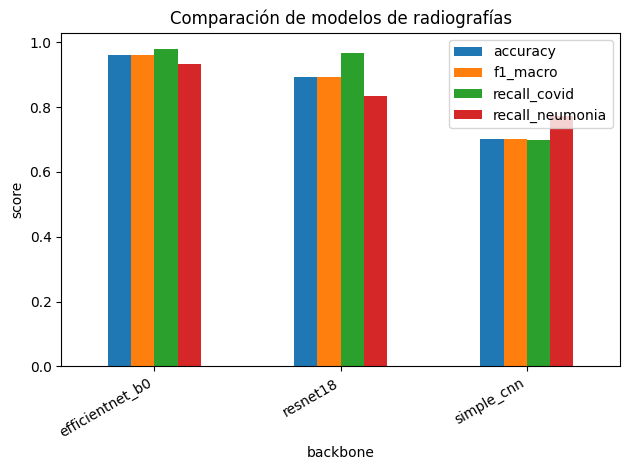

In [10]:
metrics_cols = ["accuracy", "f1_macro", "recall_covid", "recall_neumonia"]
plot_df = comparison.set_index("backbone")[metrics_cols]
ax = plot_df.plot(kind="bar")
ax.set_title("Comparación de modelos de radiografías")
ax.set_ylabel("score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


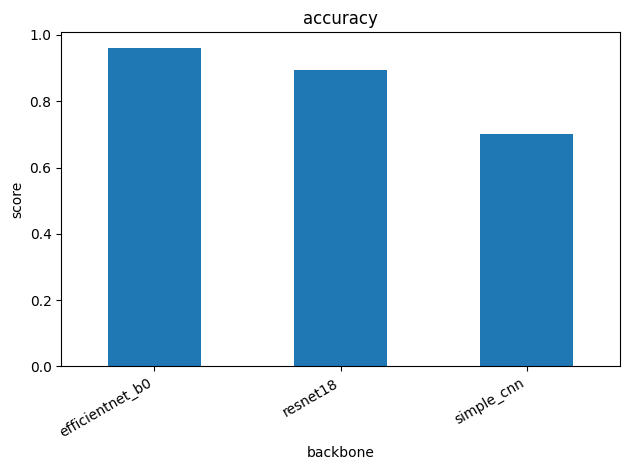

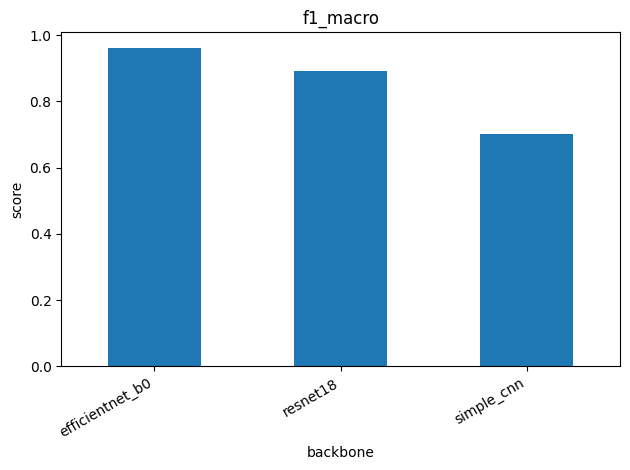

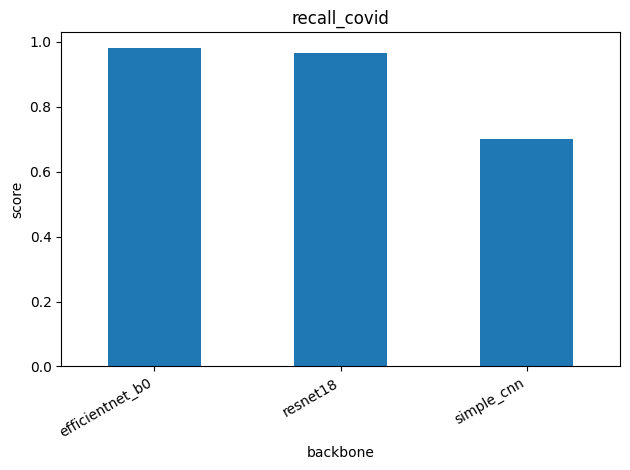

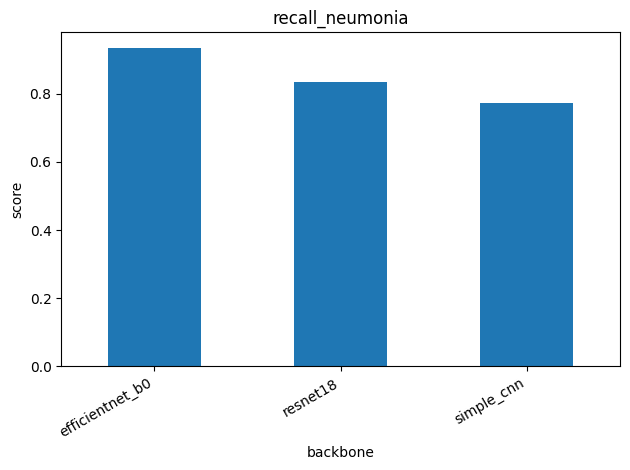

In [11]:
# Gráficas individuales para lectura clara
for metric in ["accuracy", "f1_macro", "recall_covid", "recall_neumonia"]:
    ax = comparison.set_index("backbone")[metric].plot(kind="bar")
    ax.set_title(metric)
    ax.set_ylabel("score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 5. Matrices de confusión

Se cargan las matrices de confusión generadas por `training.evaluate`.

models\radiography\rx-efficientnetb0-20260515-2b92eec9\confusion_matrix.png


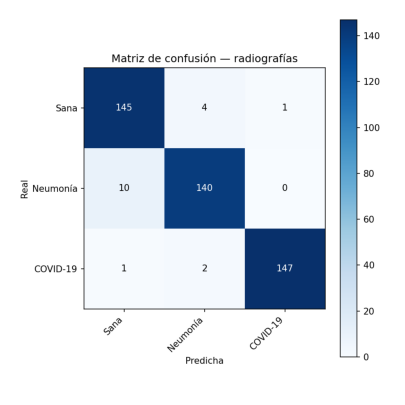

models\radiography\rx-resnet18-20260515-d397f8e5\confusion_matrix.png


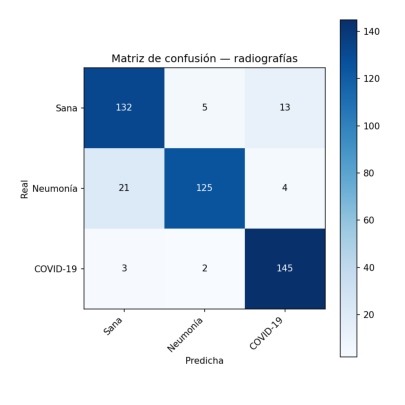

models\radiography\rx-simplecnn-20260515-e8ac76f0\confusion_matrix.png


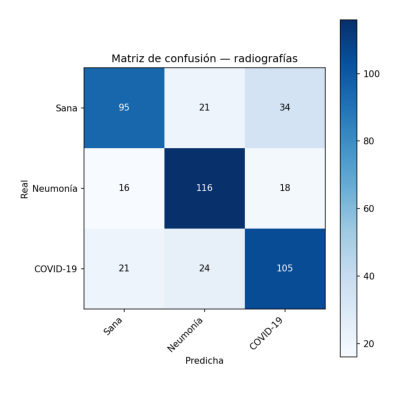

=== Matrices de confusión generadas ===

--- rx-efficientnetb0-20260515-2b92eec9 ---
Backbone: efficientnet_b0
Accuracy: 0.96
F1 macro: 0.960078515151551
Recall COVID: 0.98
Recall Neumonía: 0.9333333333333333


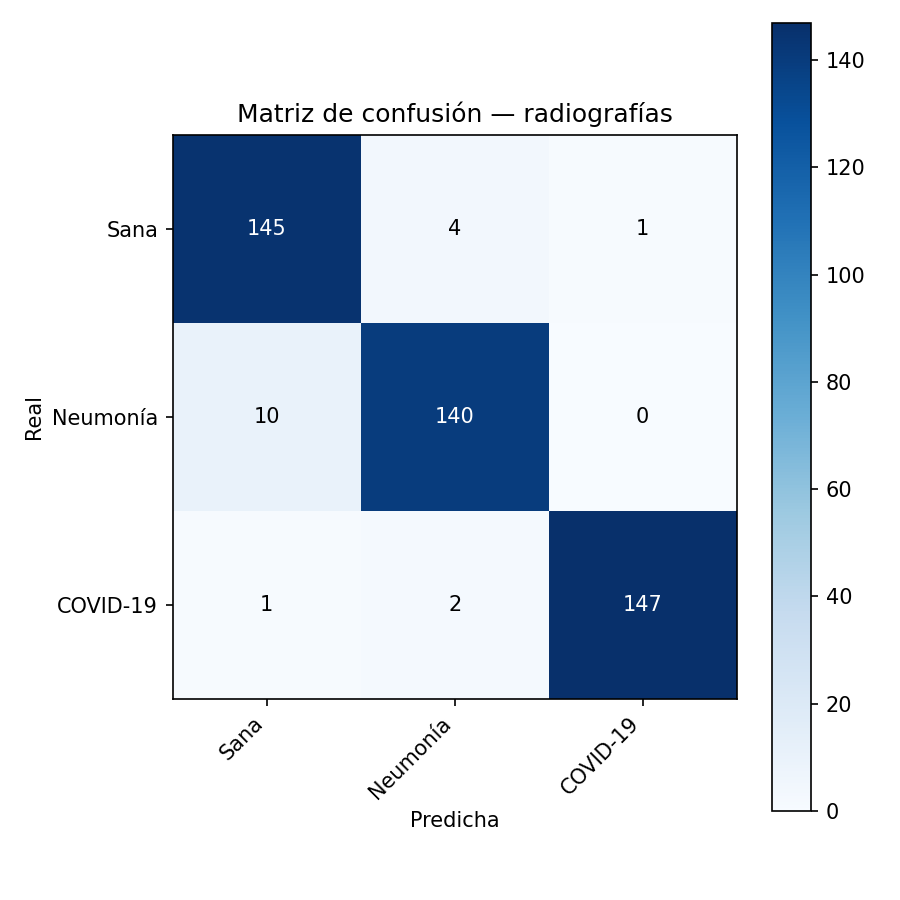


Análisis crítico:
# Análisis crítico del modelo de radiografías `rx-efficientnetb0-20260515-2b92eec9`

## 1. Resumen técnico

- **Backbone**: `efficientnet_b0`
- **Accuracy**: 0.9600
- **F1 macro**: 0.9601
- **Recall COVID-19**: 0.9800
- **Recall Neumonía**: 0.9333

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Neumonía | Sana | 10 |
| 2 | Sana | Neumonía | 4 |
| 3 | COVID-19 | Neumonía | 2 |
| 4 | Sana | COVID-19 | 1 |
| 5 | COVID-19 | Sana | 1 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente ep

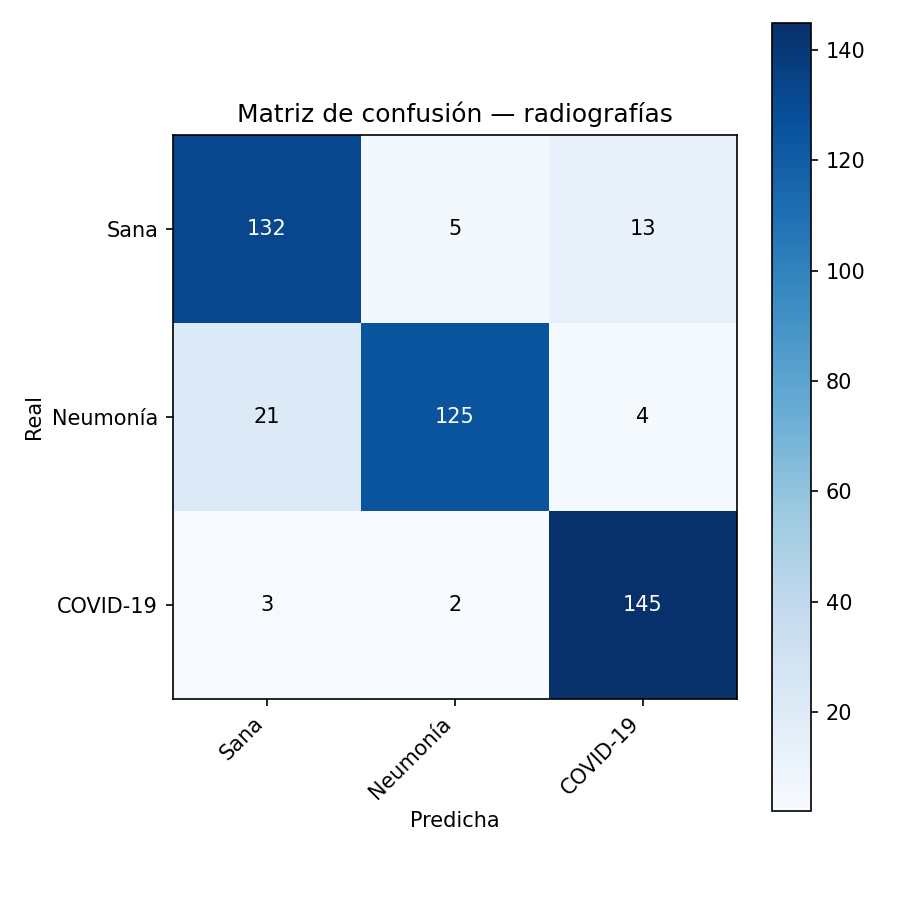


Análisis crítico:
# Análisis crítico del modelo de radiografías `rx-resnet18-20260515-d397f8e5`

## 1. Resumen técnico

- **Backbone**: `resnet18`
- **Accuracy**: 0.8933
- **F1 macro**: 0.8929
- **Recall COVID-19**: 0.9667
- **Recall Neumonía**: 0.8333

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Neumonía | Sana | 21 |
| 2 | Sana | COVID-19 | 13 |
| 3 | Sana | Neumonía | 5 |
| 4 | Neumonía | COVID-19 | 4 |
| 5 | COVID-19 | Sana | 3 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico

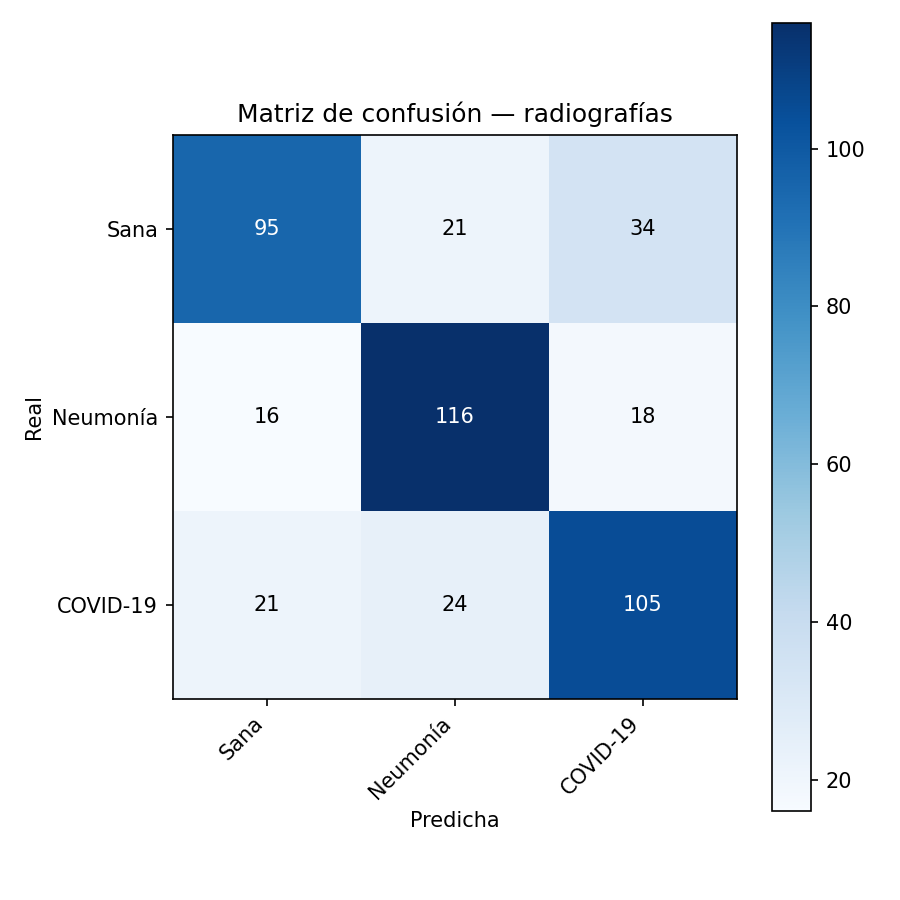


Análisis crítico:
# Análisis crítico del modelo de radiografías `rx-simplecnn-20260515-e8ac76f0`

## 1. Resumen técnico

- **Backbone**: `simple_cnn`
- **Accuracy**: 0.7022
- **F1 macro**: 0.7013
- **Recall COVID-19**: 0.7000
- **Recall Neumonía**: 0.7733

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Sana | COVID-19 | 34 |
| 2 | COVID-19 | Neumonía | 24 |
| 3 | Sana | Neumonía | 21 |
| 4 | COVID-19 | Sana | 21 |
| 5 | Neumonía | COVID-19 | 18 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epid

In [12]:
for png in sorted((ROOT/"models/radiography").glob("rx-*/confusion_matrix.png")):
    print(png.relative_to(ROOT))
    img = Image.open(png)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


from IPython.display import Image, display

print("=== Matrices de confusión generadas ===")

models_root = ROOT / "models" / "radiography"
artifact_dirs = sorted([p for p in models_root.iterdir() if p.is_dir() and p.name.startswith("rx-")])

for artifact in artifact_dirs:
    print(f"\n--- {artifact.name} ---")
    metadata = read_json(artifact / "metadata.json", default={})
    metrics = read_json(artifact / "metrics.json", default={})
    cm_path = artifact / "confusion_matrix.png"
    critical_path = artifact / "critical_analysis.md"

    print(f"Backbone: {metadata.get('config', {}).get('backbone', metadata.get('backbone', 'unknown'))}")
    if metrics:
        print(f"Accuracy: {metrics.get('accuracy')}")
        print(f"F1 macro: {metrics.get('f1_macro')}")
        print(f"Recall COVID: {metrics.get('recall_covid')}")
        print(f"Recall Neumonía: {metrics.get('recall_neumonia')}")

    if cm_path.exists():
        display(Image(filename=str(cm_path)))

    if critical_path.exists():
        print("\nAnálisis crítico:")
        print(critical_path.read_text(encoding="utf-8")[:2500])

## 6. Interpretación clínica

### Falso negativo COVID-19

Un COVID-19 clasificado como `Sana` o `Neumonía` es crítico porque puede implicar falta de aislamiento y contagio intrahospitalario.

### COVID-19 confundido con Neumonía

El tratamiento respiratorio puede compartir elementos, pero se pierde el componente epidemiológico.

### Neumonía clasificada como Sana

Puede retrasar tratamiento y seguimiento.

### Sana clasificada como patológica

Produce sobrecarga asistencial, pruebas innecesarias y ansiedad, aunque suele ser menos grave que un falso negativo clínico.

## 7. Selección del modelo

Con los resultados actuales:

- EfficientNet-B0 obtiene `accuracy = 0.9600`.
- EfficientNet-B0 obtiene `f1_macro = 0.9601`.
- EfficientNet-B0 obtiene `recall_covid = 0.9800`.
- EfficientNet-B0 obtiene `recall_neumonia = 0.9333`.

Por tanto, se selecciona **EfficientNet-B0** como modelo activo, porque ofrece mejor equilibrio entre rendimiento global y sensibilidad en enfermedades clínicamente relevantes.

## 8. Comandos usados

Preparación limpia:

```powershell
docker compose run --rm ml-inference python -m training.prepare_data `
  --raw-dir /app/COVID-19_Radiography_Dataset `
  --output-dir /app/data/covid-subset `
  --limit-per-class 1000 `
  --seed 42
```

Entrenamiento de modelos:

```powershell
docker compose run --rm ml-inference python -m training.train --backbone simple_cnn ...
docker compose run --rm ml-inference python -m training.train --backbone resnet18 ...
docker compose run --rm ml-inference python -m training.train --backbone efficientnet_b0 ...
```

Comparación:

```powershell
docker compose run --rm ml-inference python -m training.compare_models `
  --models-root /app/models/radiography `
  --output /app/models/radiography/comparison
```

## 9. Integración con dashboard

El dashboard llama internamente a:

```text
http://ml-inference:8001/predict
```

No usa `localhost` porque dentro del contenedor `dashboard`, localhost sería el propio dashboard.